(two_computation)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 为社会保障融资的两种计算方法

```{contents} Contents
:depth: 2
```

```{include} _admonition/gpu.md
```


除了 Anaconda 中已有的库之外，本讲座还需要以下库

In [ ]:
!pip install jax

## 概述

本讲座遵循 {cite:t}`huang1997two`，描述了关于如何从非融资（现收现付）制逐步转向完全融资制社会保障系统的两种计算实验。

随着人口老龄化，现收现付制社会保障系统面临着财务困难。

这种情况使得当今的一些政策制定者和政策顾问认为，如果早期的政策制定者建立了一个完全融资的退休系统，今天的公民会过得更好。

但是从我们今天的处境出发，向完全融资制系统转型会带来分配上的挑战，因为为非融资制系统做出贡献的老一代人可能会失去福利。

为了定量研究各种可能性，本讲座采用了一个一般均衡世代交叠模型，该模型通过纳入以下要素修改了 {cite:t}`auerbach1987dynamic` 的环境：

* 风险敏感偏好
* 寿命的不确定性
* 不可保的劳动收入风险
* 同一世代内以及跨世代的消费分布理论

通过采用 {cite:t}`hansen1995discounted` 的贴现风险敏感线性二次偏好，该模型为个人消费和储蓄提供了线性决策规则。

这使得在计算上可以追踪跨世代消费与财富的联合分布。

本讲座与另外两个讲座相关：

- {doc}`ak2` 研究了在两期 OLG 模型中，税收、转移支付和债务如何影响资本积累，介绍了本讲座所扩展的 {cite:t}`auerbach1987dynamic` 框架。

- {doc}`ak_aiyagari` 研究了在长寿命 OLG 模型中财政政策如何与预防性储蓄相互作用，使用的是离散动态规划而非本讲座采用的线性二次方法。

我们使用以下导入和配置

In [1]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
import jax.lax as lax
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

# 启用 64 位精度
jax.config.update("jax_enable_x64", True)

## 模型

### 环境

该经济体由有限寿命个人的世代交叠组成，个人最多可存活 $T_0+1$ 年，还有一个无限寿命的政府。

个人消费者和政府可以按恒定的无风险总回报率进行投资。

在生命的前 $T_1+1$ 期，消费者获得劳动收入，并将其分配于消费、税收和资产积累。

在生命的最后 $T_0-T_1$ 期（退休期），消费者获得社会保障福利，并通过动用其资产进行负储蓄。

政府对资本和劳动收入征税、发行债务、购买商品并支付退休福利。

对于任何变量 $z$，我们用下标 $t$ 表示年龄，用括号中的参数 $s$ 表示日历时间，用上标 $s-t$ 表示出生日期，因此 $z^{s-t}(s) \equiv z_t(s) \equiv z^{s-t}_t(s)$。

### 人口结构

在日期 $s$，出生一批规模为 $N_0(s)$ 的消费者队列，他们在 $s, s+1, \ldots, s+T_0$ 各期存活。

随着一个队列年龄增长，其成员根据年龄间的存活概率 $\{\alpha_t\}^{T_0}_{t=0}$ 面临随机存活，其中 $\alpha_t$ 是从年龄 $t$ 存活到 $t+1$ 的概率。

设 $N_t(s)$ 为在时间 $s$ 存活的年龄为 $t$ 的人数，设 $n$ 为恒定的人口总增长率。

在时间 $s$，年龄组 $t$ 的规模满足

$$
N_t(s) = \lambda_t \cdot N_0(s-t)
$$

其中 $\lambda_t = \prod^{t-1}_{j=0} \alpha_j$，$t = 0,\ldots,T_0$，$\lambda_0 = 1$，出生遵循 $N_0(s) = n^s \cdot N_0(0)$。

在每个时间 $s$，队列 $t$ 的人口占比为

$$
f_t = \frac{\lambda_t \cdot n^{-t}}{\sum^{T_0}_{\tau=0} \lambda_\tau \cdot n^{-\tau}}
$$

在时间 $s$ 的总人口为

$$
N(s) = N_0(0) \cdot n^s \cdot \sum^{T_0}_{t=0} n^{-t} \cdot \lambda_t.
$$

### 分布与总量

个人面临寿命不确定性和劳动收入冲击。

他们通过积累无风险资产（政府债券和实物资本）来进行自我保险，同时适当考虑他们预期将获得的社会保障福利。

设 $\epsilon^t_0$ 表示个人从出生到年龄 $t$ 所接受的随机冲击的历史。

状态向量 $x_t(s) = x_t(s; \epsilon^t_0, x_0)$ 度量资产存量以及消费者用来预测未来偏好或机会的信息变量。

该模型给出的消费是状态向量的一个依赖于时间和年龄的线性函数

$$
c_t(s; \epsilon^t_0, x_0) = \eta_{ct}(s) \cdot x_t(s; \epsilon^t_0, x_0)
$$

其中状态向量遵循线性运动定律

$$
x_{t+1}(s+1; \epsilon^{t+1}_0, x_0) = A_t(s) \cdot x_t(s; \epsilon^t_0, x_0) + C_t(s) \cdot \epsilon_{t+1}
$$

其中 $\epsilon_{t+1}$ 是满足 $E(\epsilon_{t+1}|J_t) = 0$、$E(\epsilon_{t+1} \cdot \epsilon'_{t+1}|J_t) = I$ 且 $J_t = (\epsilon^t_0, x_0)$ 的鞅差序列。

该模型给出状态向量的概率分布。

设 $\mu_t(s) = E[x_t(s)]$ 且 $\Sigma_t(s) = E[(x_t(s)-\mu_t(s))(x_t(s)-\mu_t(s))']$。

这些矩满足

$$
\mu_{t+1}(s+1) = A_t(s) \cdot \mu_t(s)
$$

$$
\Sigma_{t+1}(s+1) = A_t(s) \cdot \Sigma_t(s) \cdot A_t(s)' + C_t(s) \cdot C_t(s)'
$$

人均总消费为

$$
c(s)/N(s) = \sum^{T_0}_{t=0} \mu_{ct}(s) \cdot f_t
$$

其中 $\mu_{ct}(s)$ 是时间 $s$ 年龄为 $t$ 的人的平均消费。

年龄队列 $t$ 内的消费分布具有均值 $\mu_{ct}(s) = \eta_{ct}(s) \cdot \mu_t(s)$ 和方差 $\Sigma_{ct}(s) = \eta_{ct}(s) \cdot \Sigma_t(s) \cdot \eta_{ct}(s)'$。

### 资源约束

全经济范围的实物资源约束为

$$
g(s) \cdot N(s) + \sum^{T_0}_{t=0} c_t(s) \cdot N^{s-t}_t + K(s) = R(s-1) \cdot K(s-1) + w(s) \cdot \sum^{T_1}_{t=0} \varepsilon_t \cdot N^{s-t}_t + N_0(s) \cdot k_{-1}(s)
$$

其中 $g(s)$ 是人均政府购买，$K(s-1)$ 是实物资本，$R(s-1) = 1 + r(s-1) - \delta$ 是资产总回报，$\varepsilon_t$ 是年龄为 $t$ 的人的外生效率禀赋，$w(s)$ 是基础工资率，$N_0(s) \cdot k_{-1}(s)$ 是新生儿带来的资本，$\delta$ 是折旧率。

### 要素价格

我们考虑关于要素价格的两种备选假设：

* *小型开放经济：* $r(s-1) = r$ 和 $w(s) = w$ 是外生且恒定的。
* *封闭经济：* 要素价格由科布-道格拉斯生产函数的边际产量决定：

$$
r(s-1) = \tilde{A} \cdot \tilde{\alpha} \cdot (K(s-1)/\tilde{N}(s))^{\tilde{\alpha}-1}, \qquad
w(s) = (1-\tilde{\alpha}) \cdot \tilde{A} \cdot (K(s-1)/\tilde{N}(s))^{\tilde{\alpha}}
$$

其中 $\tilde{N}(s) = \sum^{T_1}_{t=0} \varepsilon_t \cdot N^{s-t}_t$ 是以效率单位计的总劳动投入，$\tilde{\alpha}$ 是资本的收入份额。

### 消费者的问题

个人消费者面临一个经典消费-储蓄问题的世代交叠版本（参见 {doc}`perm_income`）。

工作年龄的消费者（$t \leq T_1$）获得劳动收入 $w(s) \cdot \varepsilon_t + d_t$，其中 $d_t$ 是一个 AR(1)过程

$$
d_t = \rho_d \cdot d_{t-1} + \xi_t
$$

其中 $\xi_t$ 是方差为 $\sigma^2_d$ 的高斯白噪声。

年龄 $t$ 和时间 $s$ 的预算约束为

```{math}
:label: two_comp_budget

c_t(s) + a_t(s) = R(s-1) \cdot a_{t-1}(s-1) + w(s) \cdot \varepsilon_t + S_t(s) - T_t(s) + d_t
```

其中 $a_{t-1}(s-1)$ 是年龄 $t$ 开始时的资产持有量，$S_t(s)$ 是社会保障福利（工作时为零，退休时为 $S(s)$），税收为 $T_t(s) = \tau_0(s) + \tau_{\ell}(s)(w(s) \cdot \varepsilon_t + d_t) + \tau_a(s)(R(s-1)-1) \cdot a_{t-1}(s-1)$。

遵循 {cite:t}`hansen1995discounted`，对随机消费过程的偏好由以下递归方式定义

$$
U_t = -(\pi \cdot c_t - \gamma_t)^2/2 + \beta_t \cdot \mathcal{R}_t(U_{t+1})
$$

其中 $\mathcal{R}_t(U_{t+1}) = (2/\sigma) \cdot \log E[\exp(\sigma \cdot U_{t+1}/2) | J_t]$，$\sigma$ 是风险敏感性参数，$\beta_t = \bar{\beta} \cdot \alpha_t$ 是经存活率调整的贴现因子。

这种偏好设定给出线性决策规则，同时允许一种诱导某类预防性储蓄的风险敏感性形式。

当 $\sigma < 0$ 时，消费者偏好尽早消除不确定性，决策规则部分依赖于噪声统计量。

### 政府

政府购买商品、支付社会保障福利、对资本和劳动收入征税、没收意外遗产，并发行一期债券。

政府预算约束为

$$
\begin{aligned}
g(s) \cdot N(s) + \sum^{T_0}_{t=T_1+1} S_t(s) \cdot N^{s-t}_t + R(s-1) \cdot \sum^{T_0}_{t=1} b_{t-1}(s-1) \cdot N^{s-t}_t = \\
\sum^{T_0}_{t=0} N^{s-t}_t\{\tau_a(s)[R(s-1)-1] \cdot a_{t-1}(s-1) + \tau_{\ell}(s) \cdot w(s) \cdot \varepsilon_t\} + \tau_0 \cdot N(s) + \\
\sum^{T_0}_{t=0} b_t(s) \cdot N^{s-t}_t + R(s-1) \cdot \sum^{T_0}_{t=0} (1-\alpha_t) \cdot k_t(s-1) \cdot N^{s-t-1}_t
\end{aligned}
$$

其中 $b_t(s)$ 是时间 $s$ 由年龄为 $t$ 的个人持有的政府债务，最后一项表示遗产税。

财政制度之间的转型由日期 $0 \leq s_1 < s_2 < s_3$ 描述：

* 在 $s = 0$ 之前：初始平稳均衡
* 在 $s = 0$ 时：政府宣布政策变化
* $s \in [s_1, s_2)$：财政参数和社会保障系统发生变化
* $s \geq s_2$：新的恒定政策参数
* $s \geq s_3$：最终平稳均衡

### 均衡

我们定义以下对象：

- **配置** 是 $t = 0,\ldots,T_0$ 时 $\{c_t(s), a_t(s)\}^{s_3}_{s=0}$ 的随机过程，以及序列 $\{K(s)\}^{s_3}_{s=0}$。

- **政府政策** 是序列 $\{b(s), g(s), \tau_{\ell}(s), S(s), \tau_a(s)\}^{s_3}_{s=0}$。

- **价格系统** 是序列 $\{w(s), r(s-1)\}^{s_3}_{s=0}$。

**均衡** 是一个配置、一个价格系统和一个政府政策，使得

1. 给定价格序列和政府政策，该配置求解了家庭的最优问题，并且

2. 该配置和政府政策在每个日期 $s$ 满足政府预算约束。

在 **平稳均衡** 中，所有变量都与日历时间 $s$ 无关，这将政府预算约束简化为

$$
g + \sum^{T_0}_{t=T_1+1} S_t \cdot f_t + [R/n - 1] \cdot \bar{b} = \tau_a(R-1) \cdot \sum^{T_0}_{t=0} a_{t-1} \cdot f_t + \tau_{\ell} \cdot \sum^{T_1}_{t=0} w \cdot \varepsilon_t \cdot f_t + \frac{R}{n} \cdot \sum^{T_0}_{t=0} (1-\alpha_t) \cdot a_t \cdot f_t
$$

其中 $\bar{b}$ 是稳态下的人均政府债务。

### 转型动态

下图显示了转型过程中的年龄-时间结构。

每条水平线表示一个队列的生命周期，垂直虚线标记政策变化日期 $s_1$ 和 $s_2$。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


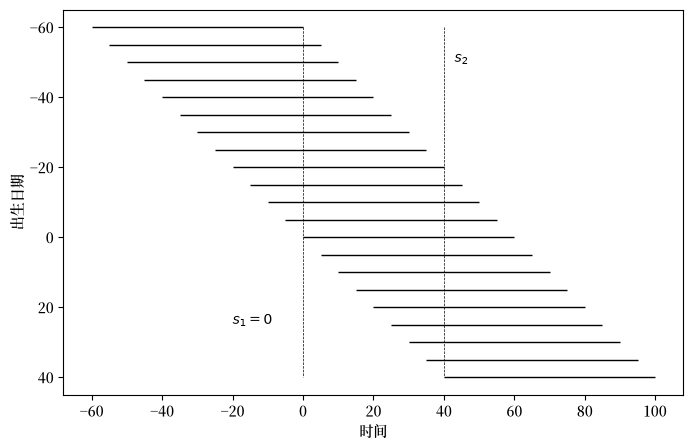

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

birth_range = np.arange(-60, 41, 5)

ax.hlines(birth_range, birth_range, birth_range + 60, 'k', linewidth=1)
ax.vlines([0, 40], -60, 40, 'k', linestyle='--', linewidth=0.5)

ax.set_ylabel("出生日期")
ax.set_xlabel("时间")

ax.text(-20, 25, r"$s_1=0$")
ax.text(43, -50, r"$s_2$")

ax.invert_yaxis()
plt.show()

#### 小型开放经济

在要素价格固定的情况下，转型具有清晰的结构：

- 在 $s_1 - T_0$ 之前出生的队列在政策变化之前死亡，不受影响。
- 在 $s_1$ 时存活的队列必须为其剩余寿命重新计算其消费-储蓄计划。
- 在 $s_1$ 和 $s_2$ 之间出生的队列面临时变的税率和福利率，而在 $s_2$ 之后出生的队列面临恒定参数。
- 转型在 $s_3 = s_2 + T_0$ 时结束，此时经历了政策变化的最后一个队列已经死亡。

由于要素价格固定，我们可以通过求解在日期 $s_1 - T_0 - 1, \ldots, s_2$ 出生的队列的决策规则来计算转型。

对于任何日期 $s$，总消费是通过对所有存活队列求和（沿年龄-时间图中的一条垂直线）计算得出的，并按其人口占比加权。

#### 封闭经济

在要素价格内生的情况下，转型更为复杂：

- 要素价格在政策参数于 $s_2$ 稳定后仍继续演变，因此我们遵循 {cite:t}`auerbach1987dynamic`，在 $s_3 = s_2 + 2T_0$ 处截断。
- 计算需要嵌套迭代：内循环确定劳动收入税率，外循环调整利率以出清要素市场。
- 储蓄行为的变化会影响资本积累，这会改变边际产量并反馈到家庭决策中。
- 较低的利率通过提高工资使年轻工人受益，但通过降低储蓄回报使退休人员受损。

## 两个实验

我们探索向完全融资制社会保障系统转型的两种策略。

在实验 1 中，政府终止社会保障福利，但通过一次性增加政府债务来补偿有资格的世代。

在实验 2 中，政府保留社会保障福利，但暂时提高税收以积累实物资本，其回报最终为社会保障支付提供资金。

两种方案都在维持跨世代福利的同时为向完全融资制社会保障的转型提供资金，但它们涉及不同数量的跨世代风险分担。

我们在固定和内生要素价格下计算两个实验，并在下文比较结果。

## 计算策略

### 动态规划

个人消费者的问题可以表述为一个贴现风险敏感线性控制问题（参见 {doc}`lqcontrol`）。

设 $x_t = [a_{t-1}, z_t]'$，其中 $z_t$ 是冲击向量。

最优值函数具有 $U_t = x'_t \cdot P_t \cdot x_t + \xi_t$ 的形式。

递归问题为

$$
U_t = \max_{u_t} \left\{ u'_t Q_t u_t + x'_t R_t x_t + \frac{2 \beta_t}{\sigma} \log E_t[\exp(\sigma U_{t+1}/2)] \right\}
$$

服从约束 $x_{t+1} = A_t x_t + B_t u_t + C_t w_{t+1}$。

我们部署两个算子

$$
\begin{gathered}
T_t(P)=P+\sigma P C_t\left(I-\sigma C_t^{\prime} P C_t\right)^{-1} C_t^{\prime} P \\
D_t(W)=R_t+A_t^{\prime}\left[\beta_t W-\beta_t^2 W B_t\left(Q_t+\beta_t B_t^{\prime} W B_t\right)^{-1} B_t^{\prime} W\right] A_t \\
\mathcal{S}_t(k, P)=\beta_t k-\left(\beta_t / \sigma\right) \log \operatorname{det}\left(I-\sigma C_t^{\prime} P C_t\right)
\end{gathered}
$$

我们用它们构造值函数递归 $P_t = (D_t \circ T_t) P_{t+1}$，$\xi_t = \mathcal{S}_t(\xi_{t+1}, P_{t+1})$，以及最优控制

$$
u_t = -F_t x_t, \qquad
F_t = \beta_t \left[Q_t + \beta_t B'_t T_t(P_{t+1}) B_t \right]^{-1} B'_t T_t(P_{t+1}) A_t.
$$

算子 $T_t$、$D_t$、$\mathcal{S}_t$ 和决策规则 $F_t$ 在 `solve_riccati_step` 中构造。

给定下一年龄的值函数参数 $(P_{t+1}, \xi_{t+1})$，它构造状态空间矩阵 $A_t$，应用叉积技巧，评估里卡蒂算子，并返回最优决策规则 $F_t$、闭环矩阵 $A^o_t = A_t - B F_t$ 以及更新后的 $(P_t, \xi_t)$

In [3]:
def solve_riccati_step(
        ε_t, β_t, Ind_work_t,
        RR, w, τ_l, τ_a, τ_0, benef,
        P_next, ξ_next,
        ρ_d, σ, B, C, R, Q, H):
    """风险敏感里卡蒂递归的一个后向步骤。"""

    A = jnp.array([
        [RR * (1.0 - τ_a) + τ_a,
         (1.0 - τ_l) * w * ε_t
         - τ_0 + benef * (1.0 - Ind_work_t),
         (1.0 - τ_l) * Ind_work_t],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, ρ_d]
    ])

    Q_scalar = Q[0, 0]
    Q_inv_scalar = 1.0 / Q_scalar
    Q_inv = jnp.array([[Q_inv_scalar]])

    # 叉积技巧：A* = A - B Q^{-1} H
    A = A - B @ Q_inv @ H

    # T_t 算子
    CTP = C.T @ P_next @ C
    PP_scalar = 1.0 - σ * CTP[0, 0]
    PP_inv_scalar = 1.0 / PP_scalar
    PC = P_next @ C
    CP = C.T @ P_next
    TP = P_next + σ * PP_inv_scalar * (PC @ CP)

    # D_t 算子和决策规则 F_t
    BTB_scalar = (B.T @ TP @ B)[0, 0]
    Q_BTB_scalar = Q_scalar + β_t * BTB_scalar
    Q_BTB_inv_scalar = 1.0 / Q_BTB_scalar
    BT_TP = B.T @ TP
    BT_TP_A = BT_TP @ A
    F = β_t * Q_BTB_inv_scalar * BT_TP_A

    TP_B = TP @ B
    middle = (β_t * TP
              - β_t**2 * Q_BTB_inv_scalar
              * (TP_B @ BT_TP))
    P = R + A.T @ middle @ A

    # S_t 算子
    log_det_PP = jnp.log(PP_scalar)
    ξ = jnp.where(
        σ != 0.0,
        β_t * (ξ_next - log_det_PP / σ),
        β_t * (ξ_next + CTP[0, 0])
    )

    Ao = A - B @ F
    F = F + Q_inv @ H

    return F.squeeze(), Ao, P, ξ

### 状态空间准备

预算约束 {eq}`two_comp_budget` 和收入过程可以写成状态空间形式。

设 $x_t = [a_{t-1}(s-1),\ 1,\ d_t]'$、$u_t = c_t(s)$、$w_{t+1} = \epsilon_{t+1}$，则有

$$
x_{t+1} = A_t x_t + B u_t + C w_{t+1}
$$

其中

$$
\begin{aligned}
A_t = \begin{bmatrix}
R(s\!-\!1)(1-\tau^a_t(s))+\tau^a_t(s) & (1-\tau_\ell(s))w(s)\varepsilon_t - \tau_0(s) + S_t(s) & \mathbf{1}^{\text{work}}_t(1-\tau_\ell(s)) \\
0 & 1 & 0 \\
0 & 0 & \rho_d
\end{bmatrix},
\end{aligned}
$$
$$
\begin{aligned}
B &= \begin{bmatrix} -1 \\ 0 \\ 0 \end{bmatrix},\\
C &= \begin{bmatrix} 0 \\ 0 \\ \sigma_d \end{bmatrix}
\end{aligned}
$$

且 $\mathbf{1}^{\text{work}}_t$ 表示行为主体是否处于工作年龄。

每期回报 $-\tfrac{1}{2}(\pi c_t - \gamma)^2$ 在控制变量与状态变量之间引入一个叉积项 $H$。

这可以使用叉积技巧消除（参见 {doc}`cross_product_trick`）：

$$
A^* = A - BQ^{-1}H, \qquad R^* = R - H'Q^{-1}H.
$$

### 均值和协方差

定义 $A_o = A - BF$ 为闭环转移矩阵，使得 $x_{t+1} = A_o x_t + C w_{t+1}$ 且无条件矩满足

$$
\mu_{t+1} = A_{o,t} \mu_t, \qquad
\Sigma_{t+1} = A_{o,t} \Sigma_t A_{o,t}' + CC'.
$$

矩递归实现为 `forward_moment_step`，它按一个年龄步长传播均值向量和协方差矩阵，并将消费统计量作为副产品计算。

In [4]:
def forward_moment_step(μx_t, Σx_t, Ao_t, F_t, CCT):
    """前向矩递归的一个步骤。"""

    μx_next = Ao_t @ μx_t
    μc_t = -F_t @ μx_t
    Σx_next = CCT + Ao_t @ Σx_t @ Ao_t.T
    Vc_t = F_t @ Σx_t @ F_t.T
    return μx_next, μc_t, Σx_next, Vc_t

### 计算转型

在 $s$ 出生的队列在 $s, s+1, \ldots, s+T_0$ 各期存活，在 $s, s+1, \ldots, s+T_1$ 各期工作。

设 $0 \leq s_1 < s_2 < s_3$。

- 在 $s = 0$ 时，政府宣布在 $s = s_1$ 和 $s = s_2$ 之间的政策变化。
- 从 $s = s_2$ 起，政府政策永久保持恒定。
- 从 $s = s_3$ 起，实现向最终平稳均衡的收敛（在小型开放经济中，$s_3 = s_2 + T_0$）。

受影响的队列是那些在 $s = s_1 - T_0, s_1 - T_0 + 1, \ldots, s_2$ 出生的队列。

在所有练习中，我们设置 $T_0 = 65$、$T_1 = 43$、$s_1 = 0$ 和 $s_2 = 40$。

## 校准

模型参数设置如下。

### 偏好参数

| 参数 | 描述 | 值 |
|-----------|-------------|-------|
| $\{\alpha_t\}_{t=0}^{T_0}$ | 年龄间存活概率 | {cite:t}`faber1982life` |
| $\pi$ | 消费偏好参数 | 1.0 |
| $\sigma$ | 风险敏感性参数 | $-0.05$ |
| $\bar{\gamma}$ | 偏好冲击参数 | 7.0 |
| $\tilde{\beta}$ | 贴现因子 | 0.986 |
| $T_0$ | 最大年龄 | 65 |
| $T_1$ | 退休年龄 | 43 |
| $n$ | 人口总增长率 | 1.012 |

### 技术参数

| 参数 | 描述 | 值 |
|-----------|-------------|-------|
| $k_{-1}$ | 初始资本禀赋 | 4.0 |
| $\sigma_d$ | 收入冲击的标准差 | 0.85 |
| $\rho_d$ | 收入冲击的持续性 | 0.8 |
| $\delta$ | 折旧率 | 0.06 |
| $\{\varepsilon_t\}_{t=0}^{T_1}$ | 年龄-效率剖面 | {cite:t}`hansen1993cyclical` |
| $w$ | 基础工资率（外生） | 5.0147 |
| $r$ | 资本回报（外生） | 0.1275 |
| $\tilde{A}$ | 生产函数缩放系数（内生） | 2.2625 |
| $\tilde{\alpha}$ | 资本份额（内生） | 0.40 |

In [5]:
N_GRID_SS = 10
TOL_SS = 1e-10

T0 = 65   # 最大寿命（年龄 21 到 86）
T1 = 43   # 工作生涯长度（65 岁退休）

UNIT_GRID = jnp.linspace(0.0, 1.0, N_GRID_SS)
AGE_INDICES = jnp.arange(T0 + 2)

下面隐藏的代码单元基于 {cite:t}`faber1982life` 和 {cite:t}`hansen1993cyclical` 定义了年龄-效率剖面 $\{\varepsilon_t\}$ 和存活概率 $\{\alpha_t\}$。

In [6]:
ε_arr = jnp.array([
    0.59031284, 0.62902188, 0.66773093, 0.70643996, 0.745149,
    0.78385804, 0.82256708, 0.86127611, 0.89998515, 0.92861368,
    0.94716179, 0.9657099,  0.98425792, 1.002806,   1.0211928,
    1.0399022,  1.0584503,  1.0769984,  1.0955465,  1.1056269,
    1.1072398,  1.1088527,  1.1104656,  1.1120784,  1.1136913,
    1.1153042,  1.116917,   1.1185299,  1.1201428,  1.1185299,
    1.1136913,  1.1088527,  1.1040141,  1.0991755,  1.0943368,
    1.0894981,  1.0846595,  1.0798209,  1.0749823,  1.0611115,
    1.0382087,  1.0153058,  0.99240301, 0.96958081
])

α_arr = jnp.array([
    1.0,     0.99851, 0.99844, 0.99838, 0.99832, 0.99826, 0.9982,
    0.99816, 0.99815, 0.99819, 0.99826, 0.99834, 0.9984,  0.99843,
    0.99841, 0.99835, 0.99828, 0.99818, 0.99807, 0.99794, 0.99778,
    0.99759, 0.99737, 0.99712, 0.99684, 0.99653, 0.99619, 0.9958,
    0.99535, 0.99481, 0.99419, 0.9935,  0.99278, 0.99209, 0.99148,
    0.99088, 0.99021, 0.98942, 0.98851, 0.98746, 0.98625, 0.98495,
    0.9835,  0.98178, 0.97974, 0.97743, 0.97489, 0.97226, 0.96965,
    0.96715, 0.96466, 0.962,   0.95907, 0.9559,  0.95246, 0.94872,
    0.9446,  0.94017, 0.93555, 0.93077, 0.9257,  0.9203,  0.91431,
    0.90742, 0.89948
])

findfont: Failed to find font weight normal, now using 600.


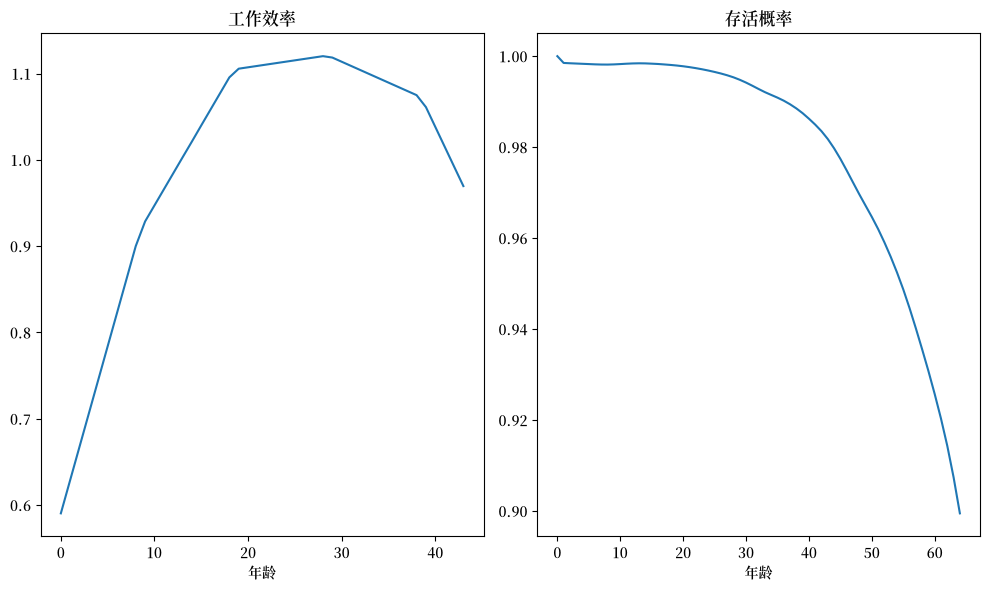

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

axs[0].plot(ε_arr)
axs[0].set_title("工作效率")
axs[0].set_xlabel("年龄")

axs[1].plot(α_arr)
axs[1].set_title("存活概率")
axs[1].set_xlabel("年龄")

plt.tight_layout()
plt.show()

我们对终端资产持有量施加较大的惩罚以强制执行生命终结条件，并将初始状态设置为 $x_0 = [k_{-1},\ 1,\ 0]'$。

In [8]:
P_end = jnp.zeros((3, 3))
P_end = P_end.at[0, 0].set(-2000000.0)
ξ_end = 0.0

x0 = jnp.array([4.0, 1.0, 0.0])
Σ0 = jnp.zeros((3, 3))

所有家庭参数被收集到一个命名元组中。

In [9]:
Household = namedtuple('Household', (
    'α_arr', 'frac', 'n', 'π', 'σ', 'k_init', 'ε_arr', 'Ind_work',
    'σ_d', 'ρ_d', 'γ_bar', 'β_arr',
    'T0', 'T1', 'T2', 'n_x', 'n_w',
    'P_end', 'ξ_end', 'x0', 'Σ0',
    'B', 'C', 'R', 'Q', 'H'
))

def create_household(α_arr=α_arr,    # 年龄间存活概率
                     n=1.012,        # 人口总增长率
                     π=1,            # 消费偏好参数	
                     σ=-0.05,        # 风险敏感性参数
                     k_init=4,       # 初始资本禀赋
                     ε_arr=ε_arr,    # 年龄-效率剖面
                     σ_d=0.85,       # 收入冲击的标准差
                     ρ_d=0.8,        # 收入冲击的持续性
                     γ_bar=7,        # 偏好冲击参数
                     β_tilde=0.986,  # 贴现因子
                     T0=65,          # 最大年龄
                     T1=43,          # 退休年龄
                     n_x=3,          # 状态数
                     n_w=1,          # 冲击数
                     P_end=P_end,    # 终端值
                     ξ_end=ξ_end,    # 终端值
                     x0=x0,          # 初始均值
                     Σ0=Σ0):         # 初始方差
    """创建带有派生数组的 Household 命名元组。"""

    α_arr = np.concatenate([α_arr, np.array([0])])
    T2 = T0 - T1
    
    frac = np.ones(T0 + 1)
    frac[1:] = np.cumprod(α_arr / n)[:-1]
    frac = frac / frac.sum()
    
    ε_arr = np.concatenate([ε_arr, np.zeros(T0 + 1 - ε_arr.size)])
    
    # 工作年龄指示器：工作时（ε > 0）为 1，退休时为 0
    Ind_work = (ε_arr != 0).astype(np.float64)
    
    β_arr = β_tilde * α_arr
    β_arr[-1] = β_tilde
    
    B = jnp.array([[-1.0, 0.0, 0.0]]).T
    C = jnp.array([[0.0, 0.0, σ_d]]).T
    
    Q = jnp.array([[-0.5 * π**2]])
    H = jnp.array([[0.0, 0.5 * π * γ_bar, 0.0]])

    # 应用叉积技巧：R* = R - H'Q^{-1}H
    R_base = np.array([[0.0, 0.0, 0.0],
                       [0.0, -0.5 * γ_bar**2, 0.0],
                       [0.0, 0.0, 0.0]])
    H_np = np.array([[0.0, 0.5 * π * γ_bar, 0.0]])
    Q_inv_np = np.array([[1.0 / (-0.5 * π**2)]])
    R = jnp.array(R_base - H_np.T @ Q_inv_np @ H_np)
    
    return Household(
        α_arr=jnp.array(α_arr), frac=jnp.array(frac), n=n, π=π, σ=σ,
        k_init=k_init, ε_arr=jnp.array(ε_arr), Ind_work=jnp.array(Ind_work),
        σ_d=σ_d, ρ_d=ρ_d, γ_bar=γ_bar, β_arr=jnp.array(β_arr),
        T0=T0, T1=T1, T2=T2, n_x=n_x, n_w=n_w,
        P_end=P_end, ξ_end=ξ_end, x0=x0, Σ0=Σ0,
        B=B, C=C, R=R, Q=Q, H=H
    )

In [10]:
hh = create_household()

平稳人口分布如下。

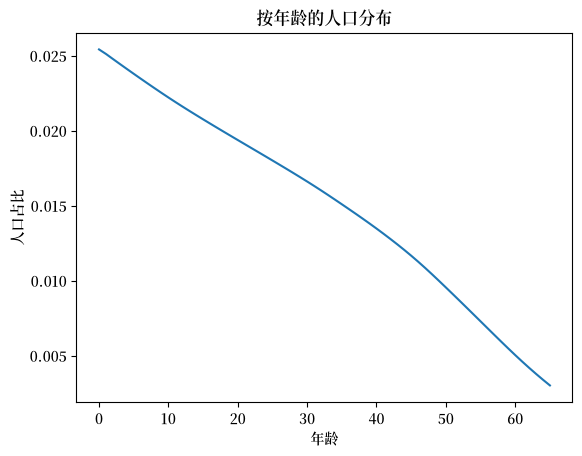

In [11]:
fig, ax = plt.subplots()
ax.plot(hh.frac)
ax.set_xlabel("年龄")
ax.set_ylabel("人口占比")
ax.set_title("按年龄的人口分布")
plt.show()

死亡率导致人口占比随年龄下降，这种人口模式是社会保障改革所涉及的跨世代再分配的核心。

在小型开放经济假设下，要素价格固定于校准值；在封闭经济假设下，它们由科布-道格拉斯边际产量决定

In [12]:
Tech = namedtuple('Tech', ('δ', 'w', 'r', 'RR', 'A', 'α_tilde'))

def create_Tech(δ=0.06, w=5.0147, r=0.1275,
                A=2.2625, α_tilde=0.40):
    """创建带有要素价格参数的 Tech 命名元组。"""

    RR = 1 + r - δ

    return Tech(δ=δ, w=w, r=r, RR=RR, A=A, α_tilde=α_tilde)

In [13]:
tech = create_Tech()

## 个人最优性

### 稳态计算

有了 `solve_riccati_step` 和 `forward_moment_step`，稳态计算分三个阶段进行。

```{prf:algorithm} 稳态计算
1. **后向递归：** 从年龄 $T_0$ 向下扫描到 $0$。
     在每个年龄 $t$，调用 `solve_riccati_step` 获得
     决策规则 $F_t$、闭环矩阵 $A^o_t$、
     值函数矩阵 $P_t$ 和确定性等价 $\xi_t$。

2. **前向模拟：** 从年龄 $0$ 向上扫描到 $T_0$。
     在每个年龄 $t$，调用 `forward_moment_step` 传播
     状态向量的均值 $\mu_{x,t}$ 和协方差 $\Sigma_{x,t}$，
     并记录平均消费 $\mu_{c,t}$ 及其方差 $V_{c,t}$。

3. **预算失衡：** 跨队列汇总。
     对税收（劳动、资本、总额）求和，
     减去福利支付，加上意外遗产，
     并返回政府预算缺口。
```

*阶段 1。* 后向递归从年龄 $T_0$ 扫描到 $0$，在每个年龄应用 `solve_riccati_step`

In [14]:
def _ss_backward_recursion(
        ε_arr, β_arr, Ind_work,
        RR, w, τ_l, τ_a, τ_0, benef,
        P_end, ξ_end,
        ρ_d, σ, B, C, R, Q, H):
    """在所有年龄上的后向里卡蒂扫描。"""
    
    ε_rev = ε_arr[::-1]
    β_rev = β_arr[::-1]
    Ind_work_rev = Ind_work[::-1]

    def backward_step(carry, inputs):
        P_next, ξ_next = carry
        ε_t, β_t, Ind_work_t = inputs
        F, Ao, P, ξ = solve_riccati_step(
            ε_t, β_t, Ind_work_t,
            RR, w, τ_l, τ_a, τ_0, benef,
            P_next, ξ_next,
            ρ_d, σ, B, C, R, Q, H
        )
        return (P, ξ), (F, Ao, P, ξ)

    init_carry = (P_end, ξ_end)
    _, (F_rev, Ao_rev, P_rev, ξ_rev) = lax.scan(
        backward_step, init_carry,
        (ε_rev, β_rev, Ind_work_rev)
    )

    F_arr = F_rev[::-1]
    Ao_arr = Ao_rev[::-1]
    P_inner = P_rev[::-1]
    ξ_inner = ξ_rev[::-1]

    P_arr = jnp.concatenate(
        [P_inner, P_end[None, :, :]], axis=0
    )
    ξ_arr = jnp.concatenate(
        [ξ_inner, jnp.array([ξ_end])]
    )

    return F_arr, Ao_arr, P_arr, ξ_arr

*阶段 2。* 前向递归将均值和协方差从年龄 $0$ 传播到 $T_0$

In [15]:
def _ss_forward_simulation(
        Ao_arr, F_arr, x0, Σ0, C):
    """使用 forward_moment_step 的前向矩扫描。"""

    CCT = C @ C.T

    def forward_step(carry, inputs):
        μx_t, Σx_t = carry
        Ao_t, F_t = inputs
        result = forward_moment_step(
            μx_t, Σx_t, Ao_t, F_t, CCT
        )
        μx_next, μc_t, Σx_next, Vc_t = result
        return (μx_next, Σx_next), \
            (μx_next, μc_t, Σx_next, Vc_t)

    init_carry = (x0, Σ0)
    _, (μx_scn, μc_arr, Σx_scn, Vc_arr) = lax.scan(
        forward_step, init_carry, (Ao_arr, F_arr)
    )

    μx_arr = jnp.concatenate(
        [x0[None, :], μx_scn], axis=0
    )
    Σx_arr = jnp.concatenate(
        [Σ0[None, :, :], Σx_scn], axis=0
    )

    return μx_arr, μc_arr, Σx_arr, Vc_arr

*阶段 3。* 跨队列汇总税收、福利支付和意外遗产给出政府预算缺口

In [16]:
def _ss_budget_imbalance(
        μx_arr, ε_arr, frac, n, α_arr,
        RR, w, τ_l, τ_a, τ_0, benef,
        G, Gb, Ind_work):
    """汇总税收和支出。"""

    μa_arr = μx_arr[1:, 0]
    μa_last_arr = μx_arr[:-1, 0]

    τ_l_tot = jnp.sum(τ_l * ε_arr * w * frac)
    τ_a_tot = jnp.sum(
        τ_a * (RR - 1.0) * μa_last_arr * frac
    )
    τ_0_tot = jnp.sum(τ_0 * frac)

    retired_mask = 1.0 - Ind_work
    benef_tot = jnp.sum(benef * frac * retired_mask)

    Beq = jnp.sum(
        RR * (1.0 - α_arr) * frac * μa_arr / n
    )

    T_tot = τ_l_tot + τ_a_tot + τ_0_tot + Beq
    diff = (G + benef_tot - T_tot
            + (RR / n - 1.0) * Gb)

    return diff

当预算缺口等于零时，就找到了稳态。

`ss_imbalance` 将三个阶段链接成一个 JIT 编译的函数：后向递归、前向模拟和预算缺口

In [17]:
@jit
def ss_imbalance(price, policy, α_arr, ε_arr, frac,
                  n, β_arr, ρ_d, σ, B, C, R, Q, H,
                  P_end, ξ_end, x0, Σ0, Ind_work):
    """后向求解、前向模拟，并返回预算缺口。"""

    RR, w = price
    τ_l, τ_a, τ_0, benef, G, Gb = policy

    F_arr, Ao_arr, P_arr, ξ_arr = \
        _ss_backward_recursion(
            ε_arr, β_arr, Ind_work,
            RR, w, τ_l, τ_a, τ_0, benef,
            P_end, ξ_end,
            ρ_d, σ, B, C, R, Q, H
        )

    μx_arr, μc_arr, Σx_arr, Vc_arr = \
        _ss_forward_simulation(
            Ao_arr, F_arr, x0, Σ0, C
        )

    diff = _ss_budget_imbalance(
        μx_arr, ε_arr, frac, n, α_arr,
        RR, w, τ_l, τ_a, τ_0, benef,
        G, Gb, Ind_work
    )

    return (diff, P_arr, ξ_arr, Ao_arr, F_arr,
            μx_arr, μc_arr, Σx_arr, Vc_arr)

一个命名元组 `SteadyState` 将值函数参数、决策规则、矩和总量统计量收集到一个对象中，转型求解器可以将其解包

In [18]:
SteadyState = namedtuple("SteadyState", (
    "P_arr",     # 按年龄的值函数矩阵
    "ξ_arr",     # 按年龄的确定性等价调整
    "Ao_arr",    # 按年龄的闭环转移矩阵
    "F_arr",     # 按年龄的决策规则矩阵
    "μx_arr",    # 按年龄的均值状态向量
    "μc_arr",    # 按年龄的平均消费
    "Σx_arr",    # 按年龄的协方差矩阵
    "Vc_arr",    # 按年龄的消费方差
    "debt2gdp",  # 政府债务与GDP之比
    "τ_l",       # 劳动收入税率
    "benef",     # 社会保障福利水平
    "Gb",        # 人均政府债务
    "k_bar",     # 人均资本存量
    "RR",        # 资产总回报
    "w",         # 工资率
    "r",         # 利率（折旧前）
    "k2gdp"      # 资本与GDP之比
))

给定所有其他财政工具，均衡 $\tau_\ell$ 是使预算缺口归零的值。

我们通过迭代网格细化找到它：在粗网格上评估缺口，放大到最佳区间，然后重复

In [19]:
def _grid_refine(eval_fn, a_init, b_init, unit_grid, tol, max_iter):
    """迭代网格细化根搜索。

    必须在 @jit 函数内部调用。
    """

    n_grid = unit_grid.shape[0]

    def cond_fn(state):
        a, b, best_val, i = state
        return (jnp.abs(best_val) > tol) & (i < max_iter)

    def body_fn(state):
        a, b, _, i = state
        grid = a + (b - a) * unit_grid
        diffs = vmap(eval_fn)(grid)
        best_idx = jnp.argmin(jnp.abs(diffs))
        best_val = diffs[best_idx]
        idx_lo = jnp.maximum(best_idx - 1, 0)
        idx_hi = jnp.minimum(best_idx + 1, n_grid - 1)
        return (grid[idx_lo], grid[idx_hi], best_val, i + 1)

    grid = a_init + (b_init - a_init) * unit_grid
    diffs = vmap(eval_fn)(grid)
    best_idx = jnp.argmin(jnp.abs(diffs))
    best_val = diffs[best_idx]
    idx_lo = jnp.maximum(best_idx - 1, 0)
    idx_hi = jnp.minimum(best_idx + 1, n_grid - 1)

    init_state = (grid[idx_lo], grid[idx_hi], best_val, 0)
    final_state = lax.while_loop(cond_fn, body_fn, init_state)
    a_final, b_final, _, _ = final_state
    return (a_final + b_final) / 2.0

`_ss_diff_for_tau_l` 在给定 $\tau_\ell$ 处评估预算缺口，`_find_ss_tau_l` 将其包装在网格细化循环内。

In [20]:
def _ss_diff_for_tau_l(τ_l, price_arr, policy_no_τl, α_arr, ε_arr, frac, n,
                        β_arr, ρ_d, σ, B, C, R, Q, H, P_end, ξ_end, x0, Σ0,
                        Ind_work):
    """给定 τ_l 的预算失衡。"""

    τ_a, τ_0, benef, G, Gb = policy_no_τl
    policy_arr = jnp.array([τ_l, τ_a, τ_0, benef, G, Gb])
    diff, *_ = ss_imbalance(
        price_arr, policy_arr,
        α_arr, ε_arr, frac, n,
        β_arr, ρ_d, σ, B, C, R, Q, H, P_end, ξ_end, x0, Σ0,
        Ind_work
    )
    return diff

In [21]:
@jit
def _find_ss_tau_l(price_arr, policy_no_τl, α_arr, ε_arr, frac, n,
                    β_arr, ρ_d, σ, B, C, R, Q, H, P_end, ξ_end, x0, Σ0,
                    Ind_work, unit_grid):
    """找到使稳态预算平衡的 τ_l。"""

    def compute_diff(τ_l):
        return _ss_diff_for_tau_l(
            τ_l, price_arr, policy_no_τl, α_arr, ε_arr, frac, n,
            β_arr, ρ_d, σ, B, C, R, Q, H, P_end, ξ_end, x0, Σ0,
            Ind_work
        )

    return _grid_refine(compute_diff, -0.5, 1.0 - 1e-5, unit_grid, TOL_SS, 10)

GDP 是资本和劳动收入份额之和

In [22]:
def _compute_gdp(μa_arr, frac, ε_arr, Gb, r, w, n, x0_0, frac_0):
    """从总量计算 GDP。"""

    ε_agg = jnp.sum(frac * ε_arr)
    a_agg = jnp.sum(frac * μa_arr)
    k_agg = a_agg - Gb
    k_share = r * (k_agg / n + frac_0 * x0_0)
    l_share = w * ε_agg
    return k_agg, k_share + l_share

`find_ss_exo` 将各部分组合起来：它求解 $\tau_\ell$、评估完整稳态，并返回一个 `SteadyState` 命名元组

In [23]:
def find_ss_exo(price, policy_target, hh, tech):
    """通过求解 τ_l 找到外生价格下的稳态。"""

    frac, ε_arr, n, x0 = hh.frac, hh.ε_arr, hh.n, hh.x0
    RR, w = price
    r = RR - 1 + tech.δ
    
    τ_a, τ_0, benef, G, Gb = policy_target
    
    price_arr = jnp.array([RR, w])
    policy_no_τl = jnp.array([τ_a, τ_0, benef, G, Gb])
    
    τ_l = _find_ss_tau_l(
        price_arr, policy_no_τl,
        hh.α_arr, hh.ε_arr, hh.frac, hh.n,
        hh.β_arr, hh.ρ_d, hh.σ, hh.B, hh.C, hh.R, hh.Q, hh.H,
        hh.P_end, hh.ξ_end, hh.x0, hh.Σ0,
        hh.Ind_work, UNIT_GRID
    )
    
    price_arr = jnp.array([RR, w])
    policy_arr = jnp.array([float(τ_l), τ_a, τ_0, benef, G, Gb])
    diff, P_arr, ξ_arr, Ao_arr, F_arr, μx_arr, μc_arr, Σx_arr, Vc_arr = \
        ss_imbalance(
            price_arr, policy_arr,
            hh.α_arr, hh.ε_arr, hh.frac, hh.n,
            hh.β_arr, hh.ρ_d, hh.σ,
            hh.B, hh.C, hh.R, hh.Q, hh.H,
            hh.P_end, hh.ξ_end, hh.x0, hh.Σ0,
            hh.Ind_work
        )
    
    k_agg, gdp = _compute_gdp(
        μx_arr[1:, 0], frac, ε_arr,
        Gb, r, w, n, x0[0], frac[0]
    )
    debt2gdp = Gb / gdp
    k2gdp = k_agg / gdp
    
    return SteadyState(
        P_arr=P_arr, ξ_arr=ξ_arr, Ao_arr=Ao_arr, F_arr=F_arr,
        μx_arr=μx_arr, μc_arr=μc_arr, Σx_arr=Σx_arr, Vc_arr=Vc_arr,
        debt2gdp=float(debt2gdp), τ_l=float(τ_l), benef=benef, Gb=Gb, 
        k_bar=float(k_agg), RR=RR, w=w, r=float(r), k2gdp=float(k2gdp)
    )

初始财政政策设定社会保障替代率为 $\theta = 0.6$

In [24]:
aveinc = tech.w * sum(hh.ε_arr) / (hh.T1 + 1)
θ = 0.6
benef_0 = aveinc * θ

G_0 = 1.44          # 政府购买
Gb_0 = 2.8 * G_0    # 政府债务
τ_l_0 = 0.3385      # 劳动收入税
τ_a_0 = 0.30        # 资本收入税
τ_0_0 = 0           # 总额税

RR, w = tech.RR, tech.w

### 初始和终端稳态

初始稳态具有校准的替代率（$\theta = 0.6$）、正的社会保障福利，以及为匹配目标而设置的政府支出和债务。

转型日期为 $s_1 = 0$ 和 $s_2 = 40$，视界为 $S = 140$（外生价格）和 $S = 200$（内生价格）。

In [25]:
S_exo = 140
S_endo = 200
S1, S2 = 0, 40
S3 = S2 + 2 * hh.T0

RR_exo, w_exo = tech.RR, tech.w

两个辅助函数构建转型求解器所期望的价格和政策数组。

在小型开放经济假设下，价格随时间恒定。

In [26]:
def make_exo_price_seq(S, RR, w):
    """为小型开放经济构造恒定价格序列。"""

    return jnp.column_stack([jnp.full(S + 2, RR), jnp.full(S + 2, w)])

政策序列在 $s_1$ 之前将 $\tau_\ell$ 设为初始稳态值，在 $s_2$ 之后设为终端值，同时保持所有其他财政工具恒定。

In [27]:
def make_policy_seq(S, ss0_τl, ss1_τl, S1, S2, τ_a, τ_0, benef, G, Gb):
    """构造带有初始/终端
    τ_l 和恒定其他政策的政策序列。"""

    policy_seq = jnp.empty((S + 2, 6))
    policy_seq = policy_seq.at[:S1 + 1, 0].set(ss0_τl)
    policy_seq = policy_seq.at[S2 + 1:, 0].set(ss1_τl)
    policy_seq = policy_seq.at[:, 1].set(τ_a)
    policy_seq = policy_seq.at[:, 2].set(τ_0)
    policy_seq = policy_seq.at[:, 3].set(benef)
    policy_seq = policy_seq.at[:, 4].set(G)
    policy_seq = policy_seq.at[:, 5].set(Gb)
    return policy_seq

In [28]:
ss0 = find_ss_exo((RR, w), (τ_a_0, τ_0_0, benef_0, G_0, Gb_0), hh, tech)

print(f"初始稳态 (s < 0):")
print(f"  劳动税 τ_l = {ss0.τ_l:.4f}")
print(f"  利率 r - δ = {ss0.r - tech.δ:.4f}")
print(f"  资本/GDP = {ss0.k2gdp:.4f}")
print(f"  债务/GDP = {ss0.debt2gdp:.4f}")

初始稳态 (s < 0):
  劳动税 τ_l = 0.3383
  利率 r - δ = 0.0675
  资本/GDP = 3.1615
  债务/GDP = 0.5899


下图追踪了均衡劳动税率在终端稳态（无社会保障）下如何随政府债务变化

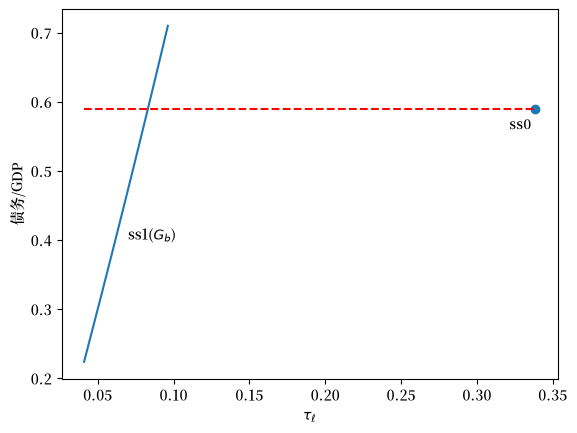

In [29]:
Gb_arr = np.linspace(0.5 * Gb_0, 1.5 * Gb_0, 20)
τl_arr = np.empty_like(Gb_arr)
debt2gdp_arr = np.empty_like(Gb_arr)

for i, Gb in enumerate(Gb_arr):
    ss = find_ss_exo((RR, w), (τ_a_0, τ_0_0, 0, G_0, Gb), hh, tech)
    τl_arr[i] = ss.τ_l
    debt2gdp_arr[i] = ss.debt2gdp

fig, ax = plt.subplots()
ax.plot(τl_arr, debt2gdp_arr)
ax.hlines(ss0.debt2gdp, τl_arr.min(),
          np.maximum(τl_arr.max(), ss0.τ_l), linestyle='--', color='r')
ax.scatter(ss0.τ_l, ss0.debt2gdp)
ax.text(ss0.τ_l * 0.95, ss0.debt2gdp * 0.95, "ss0")
ax.text(0.07, 0.4, r"ss1($G_b$)")
ax.set_xlabel(r'$\tau_\ell$')
ax.set_ylabel('债务/GDP')
plt.show()

较高的政府债务需要更大的利息支付，因此均衡劳动税上升。

标记点显示了初始稳态。

为了设定终端稳态，我们需要反转这个关系：给定目标债务与GDP之比，找到债务水平 $\bar{b}$ 和相关的 $\tau_\ell$。

In [30]:
def _compute_debt2gdp_for_Gb(
        Gb, price_arr, policy_no_Gb,
        α_arr, ε_arr, frac, n,
        β_arr, ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end, x0, Σ0,
        δ, Ind_work, unit_grid):
    """计算给定 Gb 的债务与GDP之比。"""

    RR, w = price_arr
    τ_a, τ_0, benef, G = policy_no_Gb
    r = RR - 1 + δ

    policy_no_τl = jnp.array([τ_a, τ_0, benef, G, Gb])

    # 重用 _find_ss_tau_l 而不是重复网格搜索
    τ_l = _find_ss_tau_l(
        price_arr, policy_no_τl, α_arr, ε_arr, frac, n,
        β_arr, ρ_d, σ, B, C, R, Q, H, P_end, ξ_end, x0, Σ0,
        Ind_work, unit_grid
    )

    policy_arr = jnp.array([τ_l, τ_a, τ_0, benef, G, Gb])
    _, _, _, _, _, μx_arr, _, _, _ = ss_imbalance(
        price_arr, policy_arr,
        α_arr, ε_arr, frac, n,
        β_arr, ρ_d, σ, B, C, R, Q, H, P_end, ξ_end, x0, Σ0,
        Ind_work
    )

    _, gdp = _compute_gdp(
        μx_arr[1:, 0], frac, ε_arr,
        Gb, r, w, n, x0[0], frac[0]
    )
    return Gb / gdp

`_find_Gb_for_debt2gdp` 通过网格细化搜索 $\bar{b}$ 值以匹配目标债务与GDP之比。

In [31]:
@jit
def _find_Gb_for_debt2gdp(
        debt2gdp_target, price_arr, policy_no_Gb,
        α_arr, ε_arr, frac, n,
        β_arr, ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end, x0, Σ0,
        δ, Ind_work, unit_grid, unit_grid_tau):
    """找到与目标债务与GDP之比一致的 Gb。"""

    RR, w = price_arr
    τ_a, τ_0, benef, G = policy_no_Gb

    def compute_diff_coarse(Gb):
        debt2gdp = _compute_debt2gdp_for_Gb(
            Gb, price_arr, policy_no_Gb, α_arr, ε_arr, frac, n,
            β_arr, ρ_d, σ, B, C, R, Q, H, P_end, ξ_end, x0, Σ0,
            δ, Ind_work, unit_grid_tau
        )
        return debt2gdp - debt2gdp_target

    return _grid_refine(compute_diff_coarse, -40.0, 20.0, unit_grid, TOL_SS, 5)

`ss_target_debt2gdp_exo` 找到与目标比率一致的债务水平，然后计算完整稳态。

In [32]:
def ss_target_debt2gdp_exo(debt2gdp_target, policy_target, price, hh, tech):
    """找到具有目标债务与GDP之比的稳态。"""

    τ_a, τ_0, benef, G = policy_target
    RR, w = price

    price_arr = jnp.array([RR, w])
    policy_no_Gb = jnp.array([τ_a, τ_0, benef, G])

    Gb = _find_Gb_for_debt2gdp(
        float(debt2gdp_target), price_arr, policy_no_Gb,
        hh.α_arr, hh.ε_arr, hh.frac, hh.n,
        hh.β_arr, hh.ρ_d, hh.σ, hh.B, hh.C, hh.R, hh.Q, hh.H,
        hh.P_end, hh.ξ_end, hh.x0, hh.Σ0, tech.δ,
        hh.Ind_work, UNIT_GRID, UNIT_GRID
    )

    return find_ss_exo((RR, w), (τ_a, τ_0, benef, G, float(Gb)), hh, tech)

终端稳态消除社会保障（$\theta = 0$），同时匹配初始债务与GDP之比

In [33]:
ss1 = ss_target_debt2gdp_exo(
    ss0.debt2gdp, (τ_a_0, τ_0_0, 0, G_0), (RR_exo, w_exo), hh, tech
)

print(f"\n终端稳态 (s >= s3):")
print(f"  劳动税 τ_l = {ss1.τ_l:.4f}")
print(f"  福利 θ = 0")
print(f"  资本/GDP = {ss1.k2gdp:.4f}")
print(f"  债务/GDP = {ss1.debt2gdp:.4f}")


终端稳态 (s >= s3):
  劳动税 τ_l = 0.0831
  福利 θ = 0
  资本/GDP = 4.1567
  债务/GDP = 0.5901


## 转型路径计算

转型路径描述经济体如何从初始稳态（有社会保障）转向终端稳态（改革后）。

这比稳态计算更复杂，因为价格和政策随时间变化，因此每个队列面临独特的税收和福利率的生命周期序列。

`solve_backwards` 在转型期间随时间后向求解家庭问题，计算每个日历日期 $s$ 和年龄 $t$ 的最优决策规则 $F_t(s)$ 和闭环转移矩阵 $A^o_t(s)$。

In [34]:
@jit
def solve_backwards(
        price_seq, policy_seq,
        P_arr_ss1, ξ_arr_ss1,
        ε_arr, β_arr, Ind_work,
        ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end,
        s_indices, ages):
    """在所有日期和年龄上的后向里卡蒂扫描。"""

    # 从输入数组推断维度
    n_x = P_end.shape[0]
    S = s_indices.shape[0] - 1

    def solve_all_ages(P_next_all, ξ_next_all, RR_s, w_s, τ_l, τ_a, τ_0, benef):
        def solve_one_age(t, P_next, ξ_next):
            ε_t = ε_arr[t]
            β_t = β_arr[t]
            Ind_work_t = Ind_work[t]
            F, Ao, P, ξ = solve_riccati_step(
                ε_t, β_t, Ind_work_t, RR_s, w_s, τ_l, τ_a, τ_0, benef,
                P_next, ξ_next, ρ_d, σ, B, C, R, Q, H
            )
            return F, Ao, P, ξ
        
        P_next_shifted = P_next_all[1:]
        ξ_next_shifted = ξ_next_all[1:]
        
        F_all, Ao_all, P_all, ξ_all = vmap(
            solve_one_age
        )(ages, P_next_shifted, ξ_next_shifted)
        return F_all, Ao_all, P_all, ξ_all
    
    def scan_body(carry, s_inv):
        P_next_seq, ξ_next_seq = carry
        s = S - s_inv
        
        RR_s = price_seq[s, 0]
        w_s = price_seq[s, 1]
        τ_l = policy_seq[s, 0]
        τ_a = policy_seq[s, 1]
        τ_0 = policy_seq[s, 2]
        benef = policy_seq[s, 3]
        
        F_s, Ao_s, P_s, ξ_s = solve_all_ages(
            P_next_seq, ξ_next_seq, RR_s, w_s, τ_l, τ_a, τ_0, benef
        )
        
        # 使用输入数组的已知形状构建 P_curr 和 ξ_curr
        P_curr = jnp.zeros_like(P_arr_ss1)
        P_curr = P_curr.at[:T0+1].set(P_s)
        P_curr = P_curr.at[-1].set(P_end)
        
        ξ_curr = jnp.zeros_like(ξ_arr_ss1)
        ξ_curr = ξ_curr.at[:T0+1].set(ξ_s)
        ξ_curr = ξ_curr.at[-1].set(ξ_end)
        
        output = (F_s, Ao_s, P_s, ξ_s)
        new_carry = (P_curr, ξ_curr)
        
        return new_carry, output
    
    init_carry = (P_arr_ss1, ξ_arr_ss1)
    
    # s_indices 已经具有正确的长度
    _, outputs = lax.scan(scan_body, init_carry, s_indices)
    
    F_seq, Ao_seq, P_seq_inner, ξ_seq_inner = outputs
    
    F_seq = jnp.flip(F_seq, axis=0)
    Ao_seq = jnp.flip(Ao_seq, axis=0)
    
    # 使用 price_seq 的形状构建输出数组
    P_seq = jnp.zeros((price_seq.shape[0], P_arr_ss1.shape[0], n_x, n_x))
    ξ_seq = jnp.zeros((price_seq.shape[0], ξ_arr_ss1.shape[0]))
    
    P_seq_inner = jnp.flip(P_seq_inner, axis=0)
    ξ_seq_inner = jnp.flip(ξ_seq_inner, axis=0)
    P_seq = P_seq.at[:S+1, :T0+1].set(P_seq_inner)
    ξ_seq = ξ_seq.at[:S+1, :T0+1].set(ξ_seq_inner)
    
    P_seq = P_seq.at[:, -1].set(P_end)
    ξ_seq = ξ_seq.at[:, -1].set(ξ_end)
    P_seq = P_seq.at[-1, :].set(P_arr_ss1)
    ξ_seq = ξ_seq.at[-1, :].set(ξ_arr_ss1)
    
    return F_seq, Ao_seq, P_seq, ξ_seq

`simulate_forwards` 采用计算出的决策规则，从初始分布前向模拟经济体，追踪转型期间资产均值和方差跨队列的演变。

In [35]:
@jit
def simulate_forwards(
        Ao_seq, F_seq, μx_init, Σx_init,
        C, x0, Σ0, s_indices, ages):
    """在所有日期和年龄上的前向矩扫描。"""

    # 从输入数组推断维度
    n_x = x0.shape[0]
    CCT = C @ C.T
    S = s_indices.shape[0] - 1
    
    def simulate_all_ages(μx_curr, Σx_curr, Ao_s, F_s):
        def simulate_one_age(t, μx_t, Σx_t, Ao_t, F_t):
            return forward_moment_step(
                μx_t, Σx_t, Ao_t, F_t, CCT
            )
        
        μx_next_all, μc_all, Σx_next_all, Vc_all = vmap(simulate_one_age)(
            ages, μx_curr[:T0+1], Σx_curr[:T0+1], Ao_s, F_s
        )
        return μx_next_all, μc_all, Σx_next_all, Vc_all
    
    def scan_body(carry, s):
        μx_curr, Σx_curr = carry
        
        Ao_s = Ao_seq[s]
        F_s = F_seq[s]
        
        μx_next_inner, μc_s, Σx_next_inner, Vc_s = simulate_all_ages(
            μx_curr, Σx_curr, Ao_s, F_s
        )
        
        # 使用 μx_init 的形状
        μx_next = jnp.zeros_like(μx_init)
        μx_next = μx_next.at[0].set(x0)
        μx_next = μx_next.at[1:T0+2].set(μx_next_inner)
        
        Σx_next = jnp.zeros_like(Σx_init)
        Σx_next = Σx_next.at[0].set(Σ0)
        Σx_next = Σx_next.at[1:T0+2].set(Σx_next_inner)
        
        output = (μx_curr, μc_s, Σx_curr, Vc_s)
        new_carry = (μx_next, Σx_next)
        
        return new_carry, output
    
    init_carry = (μx_init, Σx_init)
    final_carry, outputs = lax.scan(scan_body, init_carry, s_indices)
    
    μx_seq_inner, μc_seq, Σx_seq_inner, Vc_seq = outputs
    
    # 使用推断的大小构建输出数组
    μx_seq = jnp.zeros((S + 2, T0 + 2, n_x))
    Σx_seq = jnp.zeros((S + 2, T0 + 2, n_x, n_x))
    
    μx_seq = μx_seq.at[:S+1].set(μx_seq_inner)
    Σx_seq = Σx_seq.at[:S+1].set(Σx_seq_inner)
    
    μx_seq = μx_seq.at[S+1].set(final_carry[0])
    Σx_seq = Σx_seq.at[S+1].set(final_carry[1])
    
    return μx_seq, μc_seq, Σx_seq, Vc_seq

给定候选转型税率 $\tau_\ell^{\text{trans}}$，函数 `transition_paths` 构造完整的政策序列、后向求解、前向模拟、通过跨队列汇总计算资本和债务路径，并返回我们试图驱使为零的终端债务结转。

In [36]:
@jit
def _transition_paths(
        τ_l_trans, price_seq, policy_seq,
        ss1_P_arr, ss1_ξ_arr, ss1_Gb,
        μx_init, Σx_init, k_bar_init,
        s_indices, age_range, S1, S2,
        ε_arr, β_arr, Ind_work,
        ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end, x0, Σ0,
        frac, n):
    """为给定 τ_l_trans 后向求解并前向模拟。"""

    # 从输入数组推断维度
    n_x = x0.shape[0]
    S = s_indices.shape[0] - 2

    # 通过切片派生变体
    s_indices_scan = s_indices[:-1]      # arange(S+1)
    ages = age_range[:-1]                 # arange(T0+1)
    capital_indices = s_indices[1:-1]    # arange(1, S+1)
    
    # 使用动态索引用转型税更新政策序列
    mask = (s_indices >= S1 + 1) & (s_indices <= S2)
    τ_l_col = jnp.where(mask, τ_l_trans, policy_seq[:, 0])
    policy_seq = policy_seq.at[:, 0].set(τ_l_col)
    
    # 后向求解
    F_seq, Ao_seq, P_seq, ξ_seq = solve_backwards(
        price_seq, policy_seq, ss1_P_arr, ss1_ξ_arr,
        ε_arr, β_arr, Ind_work,
        ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end,
        s_indices_scan, ages
    )

    # 前向模拟
    μx_seq, μc_seq, Σx_seq, Vc_seq = simulate_forwards(
        Ao_seq, F_seq, μx_init, Σx_init, C, x0, Σ0, s_indices_scan, ages
    )
    
    # 计算资本路径
    ε_agg = jnp.sum(ε_arr * frac)
    frac0_x0 = frac[0] * x0[0]
    
    def capital_step(k_prev, s):
        RR = price_seq[s, 0]
        w = price_seq[s, 1]
        G = policy_seq[s, 4]
        c_agg = jnp.sum(μc_seq[s] * frac)
        k_new = RR * (frac0_x0 + k_prev / n) - G - c_agg + w * ε_agg
        return k_new, k_new
    
    # capital_indices 是预先创建的 arange(1, S+1)
    _, k_path = lax.scan(capital_step, k_bar_init, capital_indices)
    k_seq = jnp.concatenate([jnp.array([k_bar_init]), k_path])
    
    # 计算债务路径
    a_seq = jnp.sum(μx_seq[1:, 1:, 0] * frac, axis=1)
    Gb_seq = a_seq - k_seq
    
    carryover = Gb_seq[-1] - ss1_Gb
    
    return carryover, μx_seq, μc_seq, k_seq, Gb_seq, F_seq, Ao_seq

`transition_paths` 解包稳态和家庭对象，并调用 JIT 编译的内部函数。

In [37]:
def transition_paths(
        τ_l_trans, price_seq, policy_seq,
        ss0, ss1, hh, tech,
        S, S1, S2, μx_init, Σx_init):
    """计算转型路径。"""

    policy_seq = jnp.asarray(policy_seq)
    price_seq = jnp.asarray(price_seq)

    # 预先创建迭代数组（对变体使用切片）
    s_indices = jnp.arange(S + 2)

    carryover, μx_seq, μc_seq, k_seq, Gb_seq, F_seq, Ao_seq = _transition_paths(
        float(τ_l_trans), price_seq, policy_seq,
        ss1.P_arr, ss1.ξ_arr, float(ss1.Gb),
        μx_init, Σx_init, float(ss0.k_bar),
        s_indices, AGE_INDICES,
        S1, S2,
        hh.ε_arr, hh.β_arr, hh.Ind_work,
        hh.ρ_d, hh.σ, hh.B, hh.C, hh.R, hh.Q, hh.H,
        hh.P_end, hh.ξ_end, hh.x0, hh.Σ0,
        hh.frac, hh.n
    )

    return (float(carryover), μx_seq, μc_seq,
            k_seq, Gb_seq, F_seq, Ao_seq)

### 打靶法

为了找到正确的转型税率，我们使用打靶法。

如果税率太低，债务会爆炸；如果太高，债务会低于目标。

均衡税率是终端债务恰好达到目标的地方。

我们首先计算两条具有不同试验税率的转型路径来说明打靶法

In [38]:
price_seq = make_exo_price_seq(S_exo, RR, w)
policy_seq_base = make_policy_seq(S_exo, ss0.τ_l, ss1.τ_l, S1, S2,
                                  τ_a_0, τ_0_0, 0, G_0, Gb_0)

τ_l_low = 0.14
τ_l_high = 0.17

_, μx_seq1, μc_seq1, k_seq1, Gb_seq1, _, _ = transition_paths(
    τ_l_low, price_seq, policy_seq_base, ss0, ss1, hh, tech,
    S_exo, S1, S2, ss0.μx_arr, ss0.Σx_arr)

_, μx_seq2, μc_seq2, k_seq2, Gb_seq2, _, _ = transition_paths(
    τ_l_high, price_seq, policy_seq_base, ss0, ss1, hh, tech,
    S_exo, S1, S2, ss0.μx_arr, ss0.Σx_arr)

我们可以绘制得到的债务路径，看看它们在两个试验税率下如何不同

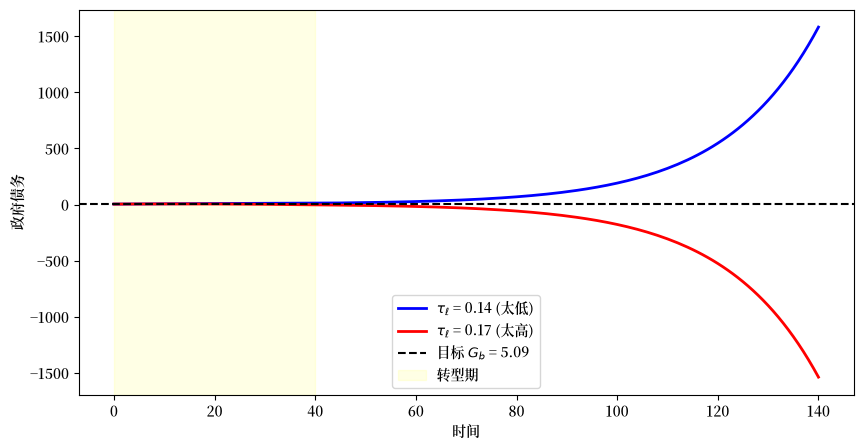

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(Gb_seq1, 'b-', linewidth=2,
        label=f'$\\tau_\\ell$ = {τ_l_low:.2f} (太低)')
ax.plot(Gb_seq2, 'r-', linewidth=2,
        label=f'$\\tau_\\ell$ = {τ_l_high:.2f} (太高)')
ax.axhline(ss1.Gb, color='k', linestyle='--',
           label=f'目标 $G_b$ = {ss1.Gb:.2f}')
ax.axvspan(S1, S2, alpha=0.1, color='yellow', label='转型期')
ax.set_xlabel('时间')
ax.set_ylabel('政府债务')
ax.legend()
plt.show()

蓝色曲线显示当税率太低时政府债务随时间增加，而红色曲线显示当税率太高时债务低于目标。

均衡转型税率位于这两个极端之间，处于终端债务恰好匹配目标 $G_b$ 的值。

二分法自动执行这个打靶过程。

对于实验 1，每个在 $s_1$ 时存活的队列还必须以其在原系统下本应获得的社会保障福利的现值进行补偿。

`_compute_compensation` 为由其剩余寿命标识的单个队列评估这个现值。

In [40]:
def _compute_compensation(
        death_time, τ_l_seq, τ_a_seq,
        benef_diff, RR_seq, w_seq,
        ε_arr, indices, ss0_τ_l):
    """一个队列失去福利的现值。"""

    n_periods = death_time + 1
    age_at_0 = T0 - death_time

    time_mask = indices < n_periods
    age_mask = indices >= age_at_0

    τ_l_cohort = jnp.where(time_mask, τ_l_seq[:T0 + 1], 0.0)
    τ_a_cohort = jnp.where(time_mask, τ_a_seq[:T0 + 1], 0.0)
    RR_cohort = jnp.where(time_mask, RR_seq[:T0 + 1], 1.0)
    w_cohort = jnp.where(time_mask, w_seq[:T0 + 1], 0.0)

    ε_masked = jnp.where(age_mask, ε_arr, 0.0)
    benef_masked = jnp.where(age_mask, benef_diff, 0.0)
    benef_masked = jnp.where(ε_masked != 0, 0.0, benef_masked)

    age_idx = jnp.clip(age_at_0 + indices, 0, T0)
    ε_cohort = jnp.where(
        time_mask, ε_arr[age_idx], 0.0
    )
    benef_cohort = jnp.where(
        time_mask, benef_diff[age_idx], 0.0
    )
    benef_cohort = jnp.where(ε_cohort != 0, 0.0, benef_cohort)

    RR_tilde_seq = RR_cohort - τ_a_cohort * (RR_cohort - 1)
    RR_tilde_seq = jnp.where(time_mask, RR_tilde_seq, 1.0)
    discount_factors = jnp.cumprod(RR_tilde_seq)

    labor_loss = w_cohort * ε_cohort * (τ_l_cohort - ss0_τ_l)

    pv_seq = jnp.where(
        time_mask,
        (benef_cohort + labor_loss) / discount_factors,
        0.0
    )

    valid = (death_time >= 0) & (death_time < T0)
    return jnp.where(valid, jnp.sum(pv_seq), 0.0)

`apply_compensation` 用 `vmap` 将此计算向量化到所有队列，并将结果加到每个队列的初始资产持有量上。

In [41]:
@jit
def apply_compensation(
        μx_arr_ss0, Σx_arr_ss0,
        τ_l_seq, τ_a_seq, benef_diff,
        RR_seq, w_seq, ε_arr, ss0_τ_l,
        ages_full, ages, x0, Σ0,
        comp_mult):
    """跨队列向量化补偿并调整初始资产。"""

    def compute_comp_for_age(age):
        death_time = T0 - age
        comp = _compute_compensation(
            death_time,
            τ_l_seq, τ_a_seq, benef_diff,
            RR_seq, w_seq, ε_arr,
            ages, ss0_τ_l
        )
        valid = (age >= 1) & (age <= T0)
        return jnp.where(valid, comp, 0.0)

    compensations = vmap(compute_comp_for_age)(ages_full)

    μx_init = jnp.zeros_like(μx_arr_ss0)
    Σx_init = jnp.zeros_like(Σx_arr_ss0)

    μx_init = μx_init.at[0].set(x0)
    Σx_init = Σx_init.at[0].set(Σ0)
    μx_init = μx_init.at[-1].set(x0)
    Σx_init = Σx_init.at[-1].set(Σ0)

    μx_init = μx_init.at[1:-1].set(μx_arr_ss0[1:-1])
    Σx_init = Σx_init.at[1:-1].set(Σx_arr_ss0[1:-1])

    # comp_mult: 0.0 = 无补偿, 1.0 = 完全补偿
    μx_init = μx_init.at[:, 0].add(comp_mult * compensations)

    return μx_init, Σx_init

`_transition_carryover` 应用补偿、求解转型，并返回终端债务结转——二分法驱使为零的标量。

In [42]:
def _transition_carryover(
        τ_l_trans, price_seq, policy_seq,
        ss1_P_arr, ss1_ξ_arr, ss1_Gb,
        ss0_μx_arr, ss0_Σx_arr, k_bar_init,
        benef_diff, ss0_τ_l, comp_mult,
        s_indices, age_range, S1, S2,
        ε_arr, β_arr, Ind_work,
        ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end, x0, Σ0,
        frac, n):
    """给定转型 τ_l 的终端债务结转。"""

    ages = age_range[:-1]  # arange(T0+1)

    # 用转型税更新政策序列
    mask = (s_indices >= S1 + 1) & (s_indices <= S2)
    τ_l_col = jnp.where(mask, τ_l_trans, policy_seq[:, 0])
    policy_seq_updated = policy_seq.at[:, 0].set(τ_l_col)

    # 计算初始条件（当 comp_mult=0.0 时补偿归零）
    μx_init, Σx_init = apply_compensation(
        ss0_μx_arr, ss0_Σx_arr,
        policy_seq_updated[:, 0], policy_seq_updated[:, 1], benef_diff,
        price_seq[:, 0], price_seq[:, 1],
        ε_arr, ss0_τ_l,
        age_range, ages, x0, Σ0,
        comp_mult
    )

    carryover, *_ = _transition_paths(
        τ_l_trans, price_seq, policy_seq,
        ss1_P_arr, ss1_ξ_arr, ss1_Gb,
        μx_init, Σx_init, k_bar_init,
        s_indices, age_range, S1, S2,
        ε_arr, β_arr, Ind_work,
        ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end, x0, Σ0,
        frac, n
    )
    return carryover

我们在 `_find_transition_tau_l` 中实现二分搜索，它在收缩区间的中点反复评估 `_transition_carryover`，直到结转被驱使为零。

In [43]:
@jit
def _find_transition_tau_l(
        price_seq, policy_seq, bounds,
        ss1_P_arr, ss1_ξ_arr, ss1_Gb,
        ss0_μx_arr, ss0_Σx_arr, k_bar_init,
        benef_diff, ss0_τ_l, comp_mult,
        s_indices, age_range, S1, S2,
        ε_arr, β_arr, Ind_work,
        ρ_d, σ, B, C, R, Q, H,
        P_end, ξ_end, x0, Σ0,
        frac, n):
    """使用二分法找到转型 τ_l。

    comp_mult 控制补偿（0 或 1）。
    """

    a, b = bounds[0], bounds[1]

    def compute_carryover(τ_l_trans):
        return _transition_carryover(
            τ_l_trans, price_seq, policy_seq,
            ss1_P_arr, ss1_ξ_arr, ss1_Gb,
            ss0_μx_arr, ss0_Σx_arr, k_bar_init,
            benef_diff, ss0_τ_l, comp_mult,
            s_indices, age_range,
            S1, S2,
            ε_arr, β_arr, Ind_work,
            ρ_d, σ, B, C, R, Q, H,
            P_end, ξ_end, x0, Σ0,
            frac, n
        )

    def cond_fn(state):
        a, b, fa, fb, i = state
        return (jnp.abs(b - a) > 1e-10) & (i < 100)

    def body_fn(state):
        a, b, fa, fb, i = state
        c = (a + b) / 2.0
        fc = compute_carryover(c)
        a_new = jnp.where(fa * fc > 0, c, a)
        b_new = jnp.where(fa * fc > 0, b, c)
        fa_new = jnp.where(fa * fc > 0, fc, fa)
        fb_new = jnp.where(fa * fc > 0, fb, fc)
        return (a_new, b_new, fa_new, fb_new, i + 1)

    fa, fb = compute_carryover(a), compute_carryover(b)
    init_state = (a, b, fa, fb, 0)
    final_state = lax.while_loop(cond_fn, body_fn, init_state)
    a_final, b_final, _, _, _ = final_state

    return (a_final + b_final) / 2.0

顶层包装器 `find_transition_exo` 设置补偿参数并调用二分求解器，然后在均衡税率处重新计算完整转型路径。

In [44]:
def find_transition_exo(price_seq, policy_seq_base, ss0, ss1,
                        hh, tech, S, S1, S2,
                        compensation_data=None,
                        τl_bounds=(0.01, 0.6)):
    """找到外生价格下的转型税率。"""

    policy_seq = jnp.asarray(policy_seq_base)
    price_seq = jnp.asarray(price_seq)
    bounds = jnp.array([τl_bounds[0], τl_bounds[1]])
    s_indices = jnp.arange(S + 2)
    
    # 设置补偿参数（不使用补偿时默认为零）
    if compensation_data is not None:
        benef_diff, ss0_τ_l = compensation_data
        comp_mult = 1.0
    else:
        benef_diff = jnp.zeros(hh.T0 + 1)
        ss0_τ_l = ss0.τ_l
        comp_mult = 0.0
    
    # 使用统一函数找到转型税
    τ_l_trans = _find_transition_tau_l(
        price_seq, policy_seq, bounds,
        ss1.P_arr, ss1.ξ_arr, float(ss1.Gb),
        ss0.μx_arr, ss0.Σx_arr, float(ss0.k_bar),
        benef_diff, float(ss0_τ_l), comp_mult,
        s_indices, AGE_INDICES,
        S1, S2,
        hh.ε_arr, hh.β_arr, hh.Ind_work,
        hh.ρ_d, hh.σ, hh.B, hh.C,
        hh.R, hh.Q, hh.H,
        hh.P_end, hh.ξ_end, hh.x0, hh.Σ0,
        hh.frac, hh.n
    )
    τ_l_trans = float(τ_l_trans)

    # 用初始条件计算最终结果
    mask = (s_indices >= S1 + 1) & (s_indices <= S2)
    τ_l_col = jnp.where(
        mask, τ_l_trans, policy_seq[:, 0]
    )
    policy_seq_final = policy_seq.at[:, 0].set(
        τ_l_col
    )

    μx_init, Σx_init = apply_compensation(
        ss0.μx_arr, ss0.Σx_arr,
        policy_seq_final[:, 0],
        policy_seq_final[:, 1],
        benef_diff,
        price_seq[:, 0], price_seq[:, 1],
        hh.ε_arr, float(ss0_τ_l),
        AGE_INDICES, AGE_INDICES[:-1],
        hh.x0, hh.Σ0, comp_mult
    )
    
    results = transition_paths(
        τ_l_trans, price_seq, policy_seq,
        ss0, ss1, hh, tech, S, S1, S2,
        μx_init, Σx_init
    )
    
    return τ_l_trans, results

对转型税率进行二分产生均衡路径。

In [45]:
τ_l_trans, results = find_transition_exo(
    price_seq, policy_seq_base, ss0, ss1,
    hh, tech, S_exo, S1, S2)

carryover, μx_seq, μc_seq, k_seq, Gb_seq, F_seq, Ao_seq = results

在基准情形（无补偿）中，社会保障福利被直接终止。

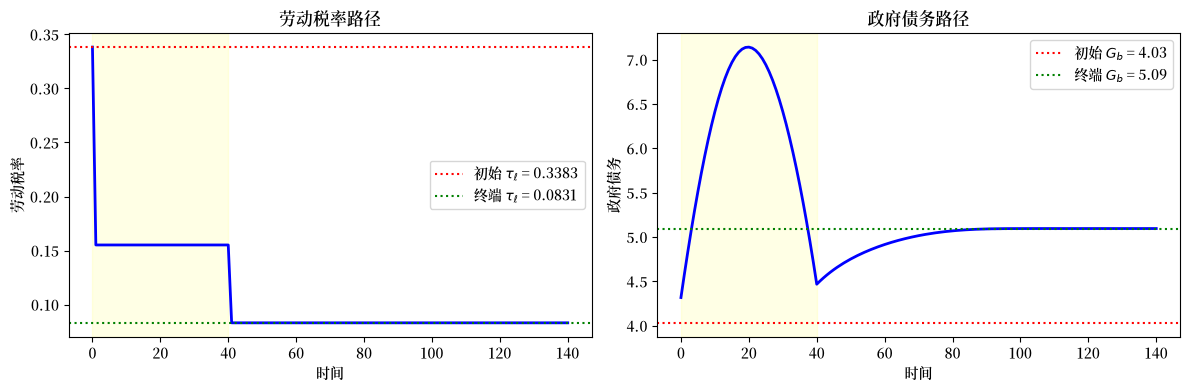

In [46]:
τ_l_seq = np.zeros(S_exo + 1)
τ_l_seq[:S1 + 1] = ss0.τ_l
τ_l_seq[S1 + 1:S2 + 1] = τ_l_trans
τ_l_seq[S2 + 1:] = ss1.τ_l

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(τ_l_seq, 'b-', linewidth=2)
axes[0].axhline(ss0.τ_l, color='r', linestyle=':',
                label=f'初始 $\\tau_\\ell$ = {ss0.τ_l:.4f}')
axes[0].axhline(ss1.τ_l, color='g', linestyle=':',
                label=f'终端 $\\tau_\\ell$ = {ss1.τ_l:.4f}')
axes[0].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[0].set_xlabel('时间')
axes[0].set_ylabel('劳动税率')
axes[0].set_title('劳动税率路径')
axes[0].legend()


axes[1].plot(Gb_seq, 'b-', linewidth=2)
axes[1].axhline(ss0.Gb, color='r', linestyle=':',
                label=f'初始 $G_b$ = {ss0.Gb:.2f}')
axes[1].axhline(ss1.Gb, color='g', linestyle=':',
                label=f'终端 $G_b$ = {ss1.Gb:.2f}')
axes[1].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[1].set_xlabel('时间')
axes[1].set_ylabel('政府债务')
axes[1].set_title('政府债务路径')
axes[1].legend()


plt.tight_layout()
plt.show()

左图显示劳动税率在转型期间下降，因为政府不再需要为社会保障福利提供资金。

右图显示政府债务从其初始水平收敛到新的稳态水平，阴影区域标记转型期 $[s_1, s_2)$。

## 实验 1：通过债务进行补偿

在这个实验中，政府终止社会保障福利，但补偿受影响的世代。

每个队列获得等于其本应获得福利现值的转移支付——一次精算公平的买断。

```{prf:algorithm} 固定要素价格 —— 实验 1（买断）
:label: two_comp_algo_buyout

这里 $s_3 = s_2 + T_0 = 105$。

*步骤 1。* 设置参数。

*步骤 2。* 求解具有恒定社会保障福利 $S$ 的初始平稳均衡：固定 $\tau_a, \tau_0, S, G, \bar{b}$，并求解 $\tau_\ell = \tau_{\ell,0}$，使得政府预算平衡：

    F(τ_ℓ) = 政府预算失衡
    找到 F(τ_ℓ) = 0 的根。

*步骤 3。* 求解无社会保障的终端平稳均衡：搜索 $\bar{b}$，使债务与GDP之比匹配目标：

    H(Gb) = 给定 Gb 的债务与GDP之比
           （内部求解 F(τ_ℓ; Gb) = 0）
    找到 H(Gb) = 目标的根。

相关的劳动税为 $\tau_{\ell,2}$。

*步骤 4。* 求解转型路径：在 $s = 0 = s_1$，所有存活的队列失去福利，年龄为 $t$ 的队列获得一次性补偿，等于失去福利的现值，以税后回报 $\tilde{R}(s) = R(s)[1-\tau_a(s)]+\tau_a(s)$ 贴现：

$$
\operatorname{comp}_t = S \sum_{j=\max(T_1-t,\,0)}^{T_0-t}
  \prod_{i=0}^{j} \tilde{R}(s+i)^{-1}.
$$

政府在 $[s_1, s_2)$ 期间设定 $\tau_{\ell,1}$，从 $s_2$ 起设定 $\tau_{\ell,2}$，在 $s_1$ 时有一次性支出增加 $\sum f_t \operatorname{comp}_t$。

找到 $\tau_{\ell,1}$，使得终端政府债务匹配目标：

    J(τ_ℓ) = 终端债务结转
    找到 J(τ_ℓ) = Gb_terminal 的根。
```

### 固定价格

我们保持要素价格固定，并为转型构造价格和政策序列。

福利差异向量 `benef_diff_exp1` 记录每个年龄的每期福利损失：退休人员失去其旧制度福利，而工人不受影响。

In [47]:
ss1_exp1_exo = ss1

price_seq_exp1_exo = make_exo_price_seq(S_exo, RR_exo, w_exo)
policy_seq_exp1_exo = make_policy_seq(S_exo, ss0.τ_l, ss1.τ_l, S1, S2,
                                      τ_a_0, τ_0_0, 0, G_0, Gb_0)

benef_diff_exp1 = jnp.zeros(hh.T0 + 1)
benef_diff_exp1 = benef_diff_exp1.at[hh.T1 + 1:].set(ss0.benef)

函数 `buyout_compensation_exp1_exo` 为每个在改革日期存活的队列计算现值补偿，并将其加到其初始资产上。

然后我们求解带买断和不带买断的转型税率，以便比较两条路径。

In [48]:
def buyout_compensation_exp1_exo(τ_l_trans, policy_seq_base, price_seq):
    """计算外生价格下的买断补偿。"""

    policy_seq = policy_seq_base.copy()
    policy_seq[S1 + 1:S2 + 1, 0] = τ_l_trans
    return apply_compensation(
        ss0.μx_arr, ss0.Σx_arr,
        policy_seq[:, 0], policy_seq[:, 1], benef_diff_exp1,
        price_seq[:, 0], price_seq[:, 1], hh.ε_arr, ss0.τ_l,
        AGE_INDICES, AGE_INDICES[:-1],
        hh.x0, hh.Σ0,
        1.0  # comp_mult = 1.0 表示完全补偿
    )

# 带买断求解
τ_l_exp1_exo_bo, results_exp1_exo_bo = find_transition_exo(
    price_seq_exp1_exo, policy_seq_exp1_exo, ss0, ss1_exp1_exo,
    hh, tech, S_exo, S1, S2,
    compensation_data=(benef_diff_exp1, ss0.τ_l)
)

# 不带买断求解（用于比较）
τ_l_exp1_exo_nb, results_exp1_exo_nb = find_transition_exo(
    price_seq_exp1_exo, policy_seq_exp1_exo, ss0, ss1_exp1_exo,
    hh, tech, S_exo, S1, S2
)

我们比较带买断补偿和不带买断补偿的转型路径。

In [49]:
exp1_exo = {
    'ss0': ss0, 'ss1': ss1_exp1_exo,
    'τ_l_buyout': τ_l_exp1_exo_bo, 'τ_l_no_buyout': τ_l_exp1_exo_nb,
    'results_buyout': results_exp1_exo_bo,
    'results_no_buyout': results_exp1_exo_nb,
    'hh': hh, 'tech': tech
}

下图显示买断如何重塑跨队列的初始资产持有量。

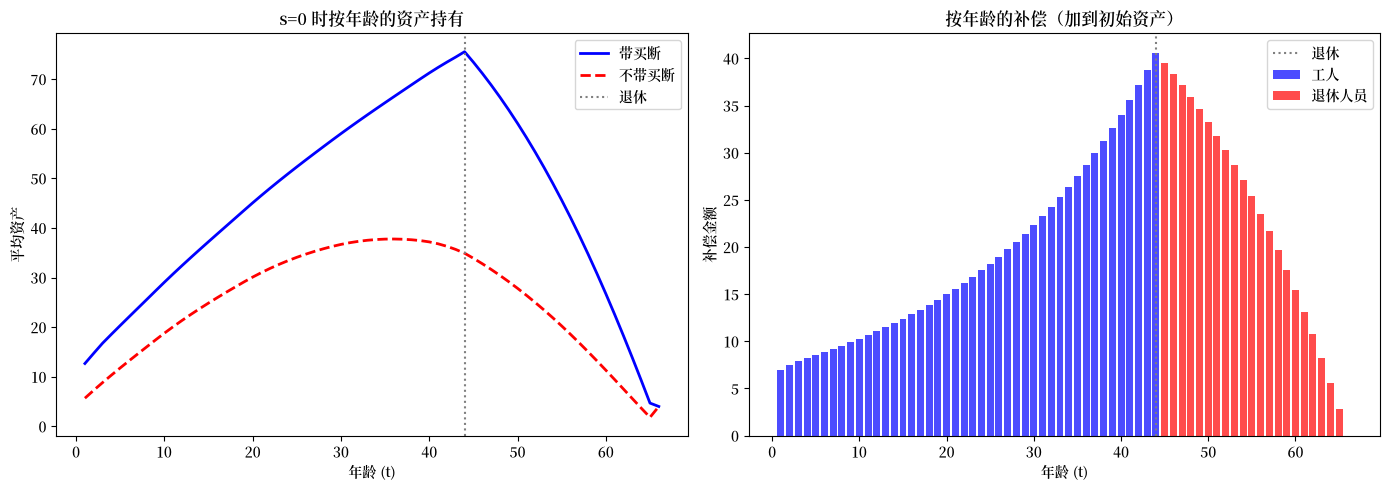

In [50]:
# 提取结果
_, μx_seq_bo, μc_seq_bo, k_seq_bo, Gb_seq_bo, _, _ = exp1_exo['results_buyout']
results_nb = exp1_exo['results_no_buyout']
_, μx_seq_nb, μc_seq_nb, k_seq_nb, Gb_seq_nb, _, _ = results_nb

# 时间 s=0 时按年龄的平均资产（带买断 vs 不带买断）
μa_bo = μx_seq_bo[0, 1:, 0]  # s=0 时带买断的资产
μa_nb = μx_seq_nb[0, 1:, 0]  # s=0 时不带买断的资产

# 补偿 = 初始资产的差异
compensation_by_age = μa_bo - μa_nb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 资产剖面
ages = np.arange(1, hh.T0 + 2)
axes[0].plot(ages, μa_bo, 'b-', linewidth=2, label='带买断')
axes[0].plot(ages, μa_nb, 'r--', linewidth=2, label='不带买断')
axes[0].axvline(hh.T1 + 1, color='gray', linestyle=':', label='退休')
axes[0].set_xlabel('年龄 (t)')
axes[0].set_ylabel('平均资产')
axes[0].set_title('s=0 时按年龄的资产持有')
axes[0].legend()


# 补偿直方图
working_ages = ages[ages <= hh.T1 + 1]
retired_ages = ages[ages > hh.T1 + 1]
comp_working = compensation_by_age[:hh.T1 + 1]
comp_retired = compensation_by_age[hh.T1 + 1:]

axes[1].bar(working_ages, comp_working,
            color='blue', alpha=0.7, label='工人')
axes[1].bar(retired_ages, comp_retired,
            color='red', alpha=0.7, label='退休人员')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axvline(hh.T1 + 1, color='gray', linestyle=':', label='退休')
axes[1].set_xlabel('年龄 (t)')
axes[1].set_ylabel('补偿金额')
axes[1].set_title('按年龄的补偿（加到初始资产）')
axes[1].legend()


plt.tight_layout()
plt.show()

退休人员获得最大的补偿，因为他们本预期在余生中获得福利。

年长工人获得可观的补偿，而年轻工人获得很少，因为他们有整个工作生涯来调整。

退休人员中递减的剖面反映了精算计算：年长的退休人员剩余的预期福利年数更少。

我们现在绘制两种方案下劳动税、政府债务、资本和消费的总量转型路径。

findfont: Failed to find font weight normal, now using 600.


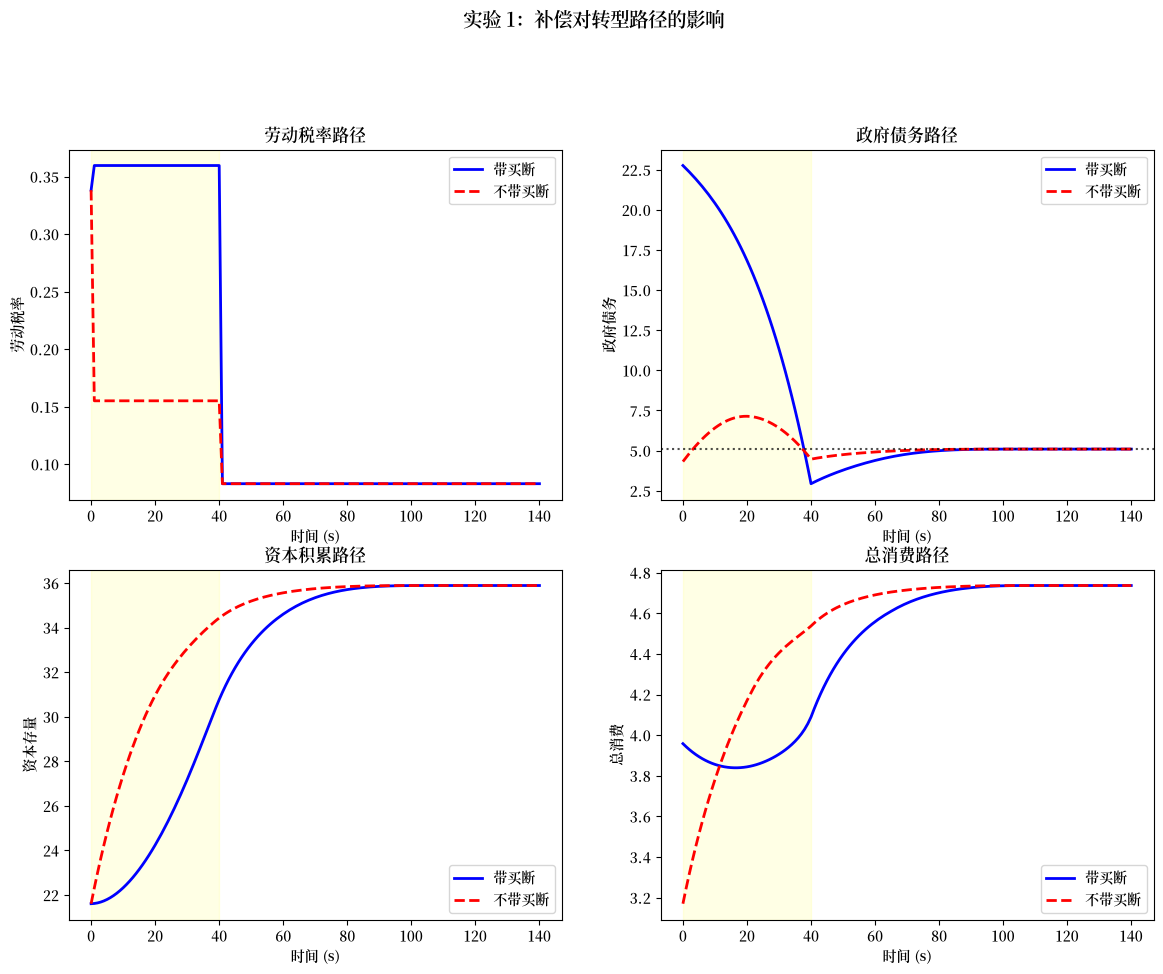

In [51]:
# hh, tech, ss0, ss1 已在作用域中——只是为了可读性从字典中别名
ss0_exp1 = exp1_exo['ss0']
ss1_exp1 = exp1_exo['ss1']

# 构造 τ_l 序列
τ_l_seq_bo = np.zeros(S_exo + 1)
τ_l_seq_bo[:S1 + 1] = ss0_exp1.τ_l
τ_l_seq_bo[S1 + 1:S2 + 1] = exp1_exo['τ_l_buyout']
τ_l_seq_bo[S2 + 1:] = ss1_exp1.τ_l

τ_l_seq_nb = np.zeros(S_exo + 1)
τ_l_seq_nb[:S1 + 1] = ss0_exp1.τ_l
τ_l_seq_nb[S1 + 1:S2 + 1] = exp1_exo['τ_l_no_buyout']
τ_l_seq_nb[S2 + 1:] = ss1_exp1.τ_l

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# τ_l 比较
axes[0, 0].plot(τ_l_seq_bo, 'b-', linewidth=2, label='带买断')
axes[0, 0].plot(τ_l_seq_nb, 'r--', linewidth=2, label='不带买断')
axes[0, 0].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[0, 0].set_xlabel('时间 (s)')
axes[0, 0].set_ylabel('劳动税率')
axes[0, 0].set_title('劳动税率路径')
axes[0, 0].legend()

# Gb 比较
axes[0, 1].plot(Gb_seq_bo, 'b-', linewidth=2, label='带买断')
axes[0, 1].plot(Gb_seq_nb, 'r--', linewidth=2, label='不带买断')
axes[0, 1].axhline(ss1_exp1.Gb, color='k', linestyle=':', alpha=0.7)
axes[0, 1].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[0, 1].set_xlabel('时间 (s)')
axes[0, 1].set_ylabel('政府债务')
axes[0, 1].set_title('政府债务路径')
axes[0, 1].legend()

# 资本路径
axes[1, 0].plot(k_seq_bo, 'b-', linewidth=2, label='带买断')
axes[1, 0].plot(k_seq_nb, 'r--', linewidth=2, label='不带买断')
axes[1, 0].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[1, 0].set_xlabel('时间 (s)')
axes[1, 0].set_ylabel('资本存量')
axes[1, 0].set_title('资本积累路径')
axes[1, 0].legend()

# 总消费
c_agg_bo = np.array(μc_seq_bo[:S_exo + 1]) @ np.array(hh.frac)
c_agg_nb = np.array(μc_seq_nb[:S_exo + 1]) @ np.array(hh.frac)

axes[1, 1].plot(c_agg_bo, 'b-', linewidth=2, label='带买断')
axes[1, 1].plot(c_agg_nb, 'r--', linewidth=2, label='不带买断')
axes[1, 1].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[1, 1].set_xlabel('时间 (s)')
axes[1, 1].set_ylabel('总消费')
axes[1, 1].set_title('总消费路径')
axes[1, 1].legend()

plt.suptitle(
    '实验 1：补偿对转型路径的影响',
    fontsize=14, y=1.02
)
plt.show()

买断方案导致私人资本初期上升较慢，因为政府必须进行大量转移支付。

两种方案都收敛到相同的终端稳态。

我们现在检查改革发生时不同年龄队列的消费路径。

findfont: Failed to find font weight normal, now using 600.


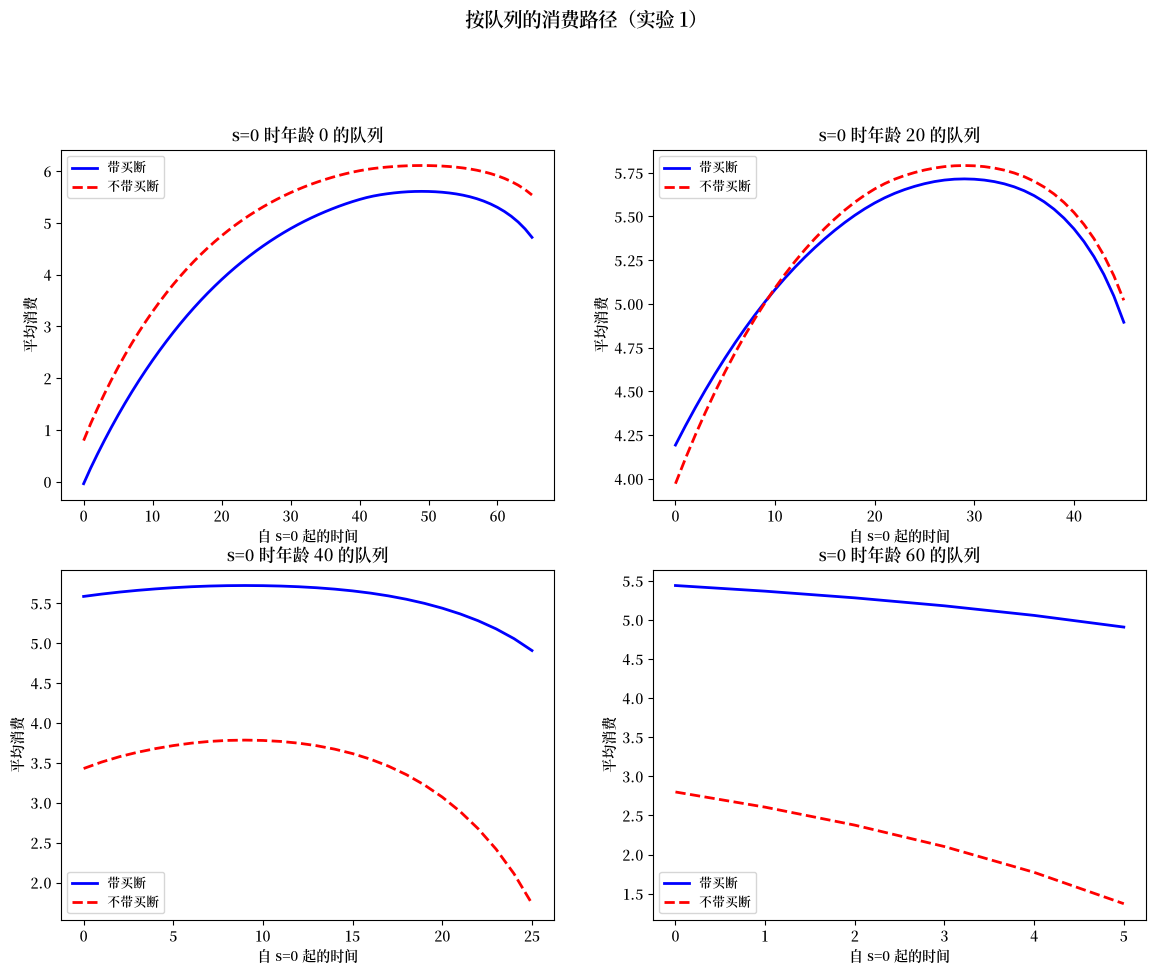

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

selected_ages = [0, 20, 40, 60]  # s=0 时不同年龄的队列

for idx, age_at_0 in enumerate(selected_ages):
    ax = axes[idx // 2, idx % 2]
    
    remaining_life = hh.T0 - age_at_0
    max_time = min(remaining_life + 1, S_exo + 1)
    
    c_bo = [μc_seq_bo[s, age_at_0 + s]
            for s in range(max_time)
            if age_at_0 + s <= hh.T0]
    c_nb = [μc_seq_nb[s, age_at_0 + s]
            for s in range(max_time)
            if age_at_0 + s <= hh.T0]
    
    ax.plot(c_bo, 'b-', linewidth=2, label='带买断')
    ax.plot(c_nb, 'r--', linewidth=2, label='不带买断')
    ax.set_xlabel('自 s=0 起的时间')
    ax.set_ylabel('平均消费')
    ax.set_title(f's=0 时年龄 {age_at_0} 的队列')
    ax.legend(fontsize=9)
    

plt.suptitle(
    '按队列的消费路径（实验 1）',
    fontsize=14, y=1.02
)
plt.show()

年轻工人（年龄 0）显示几乎相同的消费路径，因为他们获得很少补偿，且有几十年时间来调整他们的储蓄。

接近退休的工人（年龄 40）表现出更明显的差异，因为买断补偿部分抵消了他们失去的福利。

退休人员（年龄 60）显示出最戏剧性的差异：没有补偿时，他们的消费在福利结束时急剧下降，而买断方案通过替代失去的收入维持了较高的消费。

### 内生价格

在要素价格内生的情况下，储蓄行为的变化会影响资本积累，这会改变边际产量并反馈到家庭决策中。

```{prf:algorithm} 内生要素价格
:label: two_comp_algo_endo

这里 $s_3 = s_2 + 2T_0 = 170$。

步骤 1--3 与 {prf:ref}`two_comp_algo_buyout` 相同，并带有一个关于要素价格的外部不动点循环以在稳态出清要素市场。

*步骤 4。* 要素价格序列现在是内生的。

将固定价格转型求解器包装在松弛循环中：

    T(R_seq):
      1. 通过科布-道格拉斯从 R_seq 计算工资序列。
      2. 将价格视为给定，找到 J(τ_ℓ) = Gb_terminal 的根。
      3. 计算隐含的资本路径，然后计算隐含的 R*。
      返回 R* − R_seq。

    带松弛迭代 T(R_seq) = 0 直到收敛。
```

我们迭代价格序列直到要素市场出清。

In [53]:
@jit
def compute_factor_prices(k_prod, ε_bar, A, α, δ):
    """从科布-道格拉斯计算要素价格。"""

    k_per_eff = k_prod / ε_bar
    r = A * α * (k_per_eff ** (α - 1))
    w = A * (1 - α) * (k_per_eff ** α)
    RR = 1 + r - δ
    return r, w, RR

在内生价格下，寻找稳态需要一个外部不动点循环：在给定价格下求解家庭问题、计算隐含的资本存量、通过科布-道格拉斯边际产量更新价格，并重复直到收敛。

In [54]:
def find_ss_endo(
        debt2gdp_target, policy_target,
        hh, tech, RR_init=None, w_init=None,
        max_iter=50, tol=1e-5, verbose=False):
    """找到具有内生要素价格的稳态。"""

    τ_a, τ_0, benef, G = policy_target
    ε_bar = float(jnp.sum(hh.frac * hh.ε_arr))

    RR = RR_init if RR_init else tech.RR
    w = w_init if w_init else tech.w

    relaxation = 0.3

    for iteration in range(max_iter):
        try:
            ss = ss_target_debt2gdp_exo(
                debt2gdp_target,
                (τ_a, τ_0, benef, G),
                (RR, w), hh, tech
            )
        except ValueError:
            RR = RR * 0.99
            continue

        K_eff = ss.k_bar / hh.n + float(hh.frac[0] * hh.x0[0])
        r_new, w_new, RR_new = compute_factor_prices(
            K_eff, ε_bar,
            tech.A, tech.α_tilde, tech.δ
        )
        r_new = float(r_new)
        w_new = float(w_new)
        RR_new = float(RR_new)
        price_diff = abs(RR_new - RR) + abs(w_new - w)

        if verbose and iteration % 5 == 0:
            print(f"    SS 迭代 {iteration}: "
                  f"RR={RR:.6f}, w={w:.4f}, "
                  f"k_bar={ss.k_bar:.4f}")

        if price_diff < tol:
            if verbose:
                print(f"    在迭代 {iteration} 收敛")
            break

        RR = RR + relaxation * (RR_new - RR)
        w = w + relaxation * (w_new - w)

    return ss_target_debt2gdp_exo(
        debt2gdp_target,
        (τ_a, τ_0, benef, G),
        (RR, w), hh, tech
    )

价格迭代还需要转型价格路径的初始猜测，以及在每次内部求解后更新它的方法。

函数 `init_price_seq_interp` 在两个稳态价格向量之间线性插值，而 `_update_prices_from_capital` 通过科布-道格拉斯边际产量从资本路径重新计算要素价格。

In [55]:
def init_price_seq_interp(S, S1, S3, ss0_RR, ss0_w, ss1_RR, ss1_w):
    """在稳态之间线性插值价格序列。"""

    s_indices = jnp.arange(S + 2)
    t_frac = jnp.clip((s_indices - S1) / (S3 - S1), 0.0, 1.0)

    RR_seq = ss0_RR + t_frac * (ss1_RR - ss0_RR)
    w_seq = ss0_w + t_frac * (ss1_w - ss0_w)

    RR_seq = jnp.where(s_indices <= S1, ss0_RR, RR_seq)
    w_seq = jnp.where(s_indices <= S1, ss0_w, w_seq)
    RR_seq = jnp.where(s_indices >= S3, ss1_RR, RR_seq)
    w_seq = jnp.where(s_indices >= S3, ss1_w, w_seq)

    return jnp.column_stack([RR_seq, w_seq])


@jit
def _update_prices_from_capital(
        k_seq, k_bar_ss0, n, frac0_x0,
        ε_bar, A, α, δ,
        s_indices_full, ss1_RR, ss1_w, S3):
    """从资本路径计算新的价格序列。"""

    k_prev = jnp.concatenate([jnp.array([k_bar_ss0]), k_seq[:-1]])
    K_eff = k_prev / n + frac0_x0

    k_per_eff = K_eff / ε_bar
    r_new = A * α * (k_per_eff ** (α - 1))
    w_new = A * (1 - α) * (k_per_eff ** α)
    RR_new = 1 + r_new - δ

    price_seq_new = jnp.column_stack([RR_new, w_new])
    price_seq_new = jnp.concatenate([price_seq_new, price_seq_new[-1:]], axis=0)

    terminal_prices = jnp.array([[ss1_RR, ss1_w]])
    mask = s_indices_full >= S3
    price_seq_new = jnp.where(mask[:, None], terminal_prices, price_seq_new)

    return price_seq_new

顶层函数 `find_transition_endo` 将所有内容包装在松弛循环中：在每次迭代中它在当前价格下求解转型、计算隐含的资本路径、更新价格并检查收敛。

In [56]:
def find_transition_endo(price_seq, policy_seq_base,
                         ss0, ss1, hh, tech, S, S1, S2, S3,
                         compensation_data=None,
                         max_iter=50, tol=1e-3,
                         relaxation=0.5, verbose=False):
    """找到内生价格下的转型。"""

    ε_bar = float(jnp.sum(hh.frac * hh.ε_arr))
    frac0_x0 = float(hh.frac[0] * hh.x0[0])
    
    price_seq = jnp.asarray(price_seq)
    policy_seq_base = jnp.asarray(policy_seq_base)
    
    # 为价格更新预先创建迭代数组
    s_indices_full = jnp.arange(S + 2)
    
    if verbose:
        print("  开始价格迭代...")
    
    for iteration in range(max_iter):
        try:
            τ_l_trans, results = find_transition_exo(
                price_seq, policy_seq_base, ss0, ss1,
                hh, tech, S, S1, S2,
                compensation_data=compensation_data
            )
        except ValueError:
            τ_l_trans = 0.35
            results = transition_paths(
                τ_l_trans, price_seq, policy_seq_base,
                ss0, ss1, hh, tech, S, S1, S2,
                ss0.μx_arr, ss0.Σx_arr
            )
        
        _, μx_seq, μc_seq, k_seq, Gb_seq, F_seq, Ao_seq = results
        
        price_seq_new = _update_prices_from_capital(
            k_seq, float(ss0.k_bar), hh.n, float(frac0_x0), float(ε_bar),
            tech.A, tech.α_tilde, tech.δ,
            s_indices_full,
            float(ss1.RR), float(ss1.w), S3
        )
        
        price_diff = float(jnp.max(jnp.abs(price_seq_new - price_seq)))
        
        if verbose:
            print(f"  迭代 {iteration}: "
                  f"τ_l={τ_l_trans:.4f}, "
                  f"price_diff={price_diff:.6f}")
        
        if price_diff < tol:
            if verbose:
                print(f"  在迭代 {iteration} 收敛")
            break
        
        price_seq = price_seq + relaxation * (price_seq_new - price_seq)
    
    return τ_l_trans, price_seq, results

我们现在计算内生价格下的初始和终端稳态，并用价格迭代求解转型。

In [57]:
# 为初始 SS 计算内生价格
ε_bar = float(jnp.sum(hh.frac * hh.ε_arr))
K_eff_0 = ss0.k_bar / hh.n + float(hh.frac[0] * hh.x0[0])
r0_endo, w0_endo, RR0_endo = compute_factor_prices(
    K_eff_0, ε_bar,
    tech.A, tech.α_tilde, tech.δ
)
r0_endo = float(r0_endo)
w0_endo = float(w0_endo)
RR0_endo = float(RR0_endo)

ss0_exp1_endo = SteadyState(
    P_arr=ss0.P_arr, ξ_arr=ss0.ξ_arr, Ao_arr=ss0.Ao_arr, F_arr=ss0.F_arr,
    μx_arr=ss0.μx_arr, μc_arr=ss0.μc_arr, Σx_arr=ss0.Σx_arr, Vc_arr=ss0.Vc_arr,
    debt2gdp=ss0.debt2gdp, τ_l=ss0.τ_l, benef=ss0.benef, Gb=ss0.Gb,
    k_bar=ss0.k_bar, RR=RR0_endo, w=w0_endo, r=r0_endo, k2gdp=ss0.k2gdp
)

ss1_exp1_endo = find_ss_endo(
    ss0.debt2gdp, (τ_a_0, τ_0_0, 0, G_0), hh, tech,
    RR_init=tech.RR, w_init=tech.w, verbose=True
)

    SS 迭代 0: RR=1.067500, w=5.0147, k_bar=35.8906
    SS 迭代 5: RR=1.044957, w=5.7366, k_bar=30.4338
    SS 迭代 10: RR=1.044407, w=5.7330, k_bar=30.1611
    SS 迭代 15: RR=1.044405, w=5.7291, k_bar=30.1587
    SS 迭代 20: RR=1.044406, w=5.7284, k_bar=30.1588
    SS 迭代 25: RR=1.044406, w=5.7283, k_bar=30.1588
    在迭代 28 收敛


    SS 迭代 5: RR=1.044957, w=5.7366, k_bar=30.4338


    SS 迭代 10: RR=1.044407, w=5.7330, k_bar=30.1611


    SS 迭代 15: RR=1.044405, w=5.7291, k_bar=30.1587


    SS 迭代 20: RR=1.044406, w=5.7284, k_bar=30.1588


    SS 迭代 25: RR=1.044406, w=5.7283, k_bar=30.1588
    在迭代 28 收敛


初始价格猜测在两个稳态之间线性插值。

In [58]:
# 初始化价格序列
price_seq_exp1_endo = init_price_seq_interp(
    S_endo, S1, S3,
    float(ss0_exp1_endo.RR), float(ss0_exp1_endo.w),
    float(ss1_exp1_endo.RR), float(ss1_exp1_endo.w)
)

# 政策序列
policy_seq_exp1_endo = make_policy_seq(
    S_endo,
    ss0_exp1_endo.τ_l, ss1_exp1_endo.τ_l,
    S1, S2,
    τ_a_0, τ_0_0, 0, G_0,
    ss0_exp1_endo.Gb
)

福利差异向量记录每个年龄的福利损失，价格迭代找到带买断补偿的均衡转型路径。

In [59]:
# 买断补偿
benef_diff_exp1_endo = jnp.zeros(hh.T0 + 1)
benef_diff = ss0_exp1_endo.benef - ss1_exp1_endo.benef
benef_diff_exp1_endo = benef_diff_exp1_endo.at[
    hh.T1 + 1:
].set(benef_diff)

# 用价格迭代求解
print("\n  用内生价格求解转型...")
endo_result = find_transition_endo(
    price_seq_exp1_endo, policy_seq_exp1_endo,
    ss0_exp1_endo, ss1_exp1_endo,
    hh, tech, S_endo, S1, S2, S3,
    compensation_data=(
        benef_diff_exp1_endo,
        ss0_exp1_endo.τ_l
    ),
    verbose=True
)
τ_l_exp1_endo_bo = endo_result[0]
price_seq_exp1_endo_conv = endo_result[1]
results_exp1_endo = endo_result[2]
(_, μx_seq_exp1_endo, μc_seq_exp1_endo,
 k_seq_exp1_endo, Gb_seq_exp1_endo,
 _, _) = results_exp1_endo


  用内生价格求解转型...
  开始价格迭代...
  迭代 0: τ_l=0.3391, price_diff=0.490311
  迭代 1: τ_l=0.3549, price_diff=0.184939
  迭代 2: τ_l=0.3637, price_diff=0.064441
  迭代 3: τ_l=0.3676, price_diff=0.021013
  迭代 4: τ_l=0.3692, price_diff=0.006973
  迭代 5: τ_l=0.3698, price_diff=0.002371
  迭代 6: τ_l=0.3701, price_diff=0.000828
  在迭代 6 收敛


  迭代 0: τ_l=0.3391, price_diff=0.490311
  迭代 1: τ_l=0.3549, price_diff=0.184939
  迭代 2: τ_l=0.3637, price_diff=0.064441


  迭代 3: τ_l=0.3676, price_diff=0.021013
  迭代 4: τ_l=0.3692, price_diff=0.006973
  迭代 5: τ_l=0.3698, price_diff=0.002371


  迭代 6: τ_l=0.3701, price_diff=0.000828
  在迭代 6 收敛


存储内生价格结果以便与固定价格情形比较。

In [60]:
exp1_endo = {
    'ss0': ss0_exp1_endo, 'ss1': ss1_exp1_endo,
    'τ_l_buyout': τ_l_exp1_endo_bo,
    'price_seq': price_seq_exp1_endo_conv,
    'k_seq': k_seq_exp1_endo, 'Gb_seq': Gb_seq_exp1_endo,
    'results': results_exp1_endo,
    'μc_seq': μc_seq_exp1_endo, 'μx_seq': μx_seq_exp1_endo
}

下图比较固定和内生要素价格下的转型路径，显示一般均衡效应如何改变税收、债务、利率和工资路径。

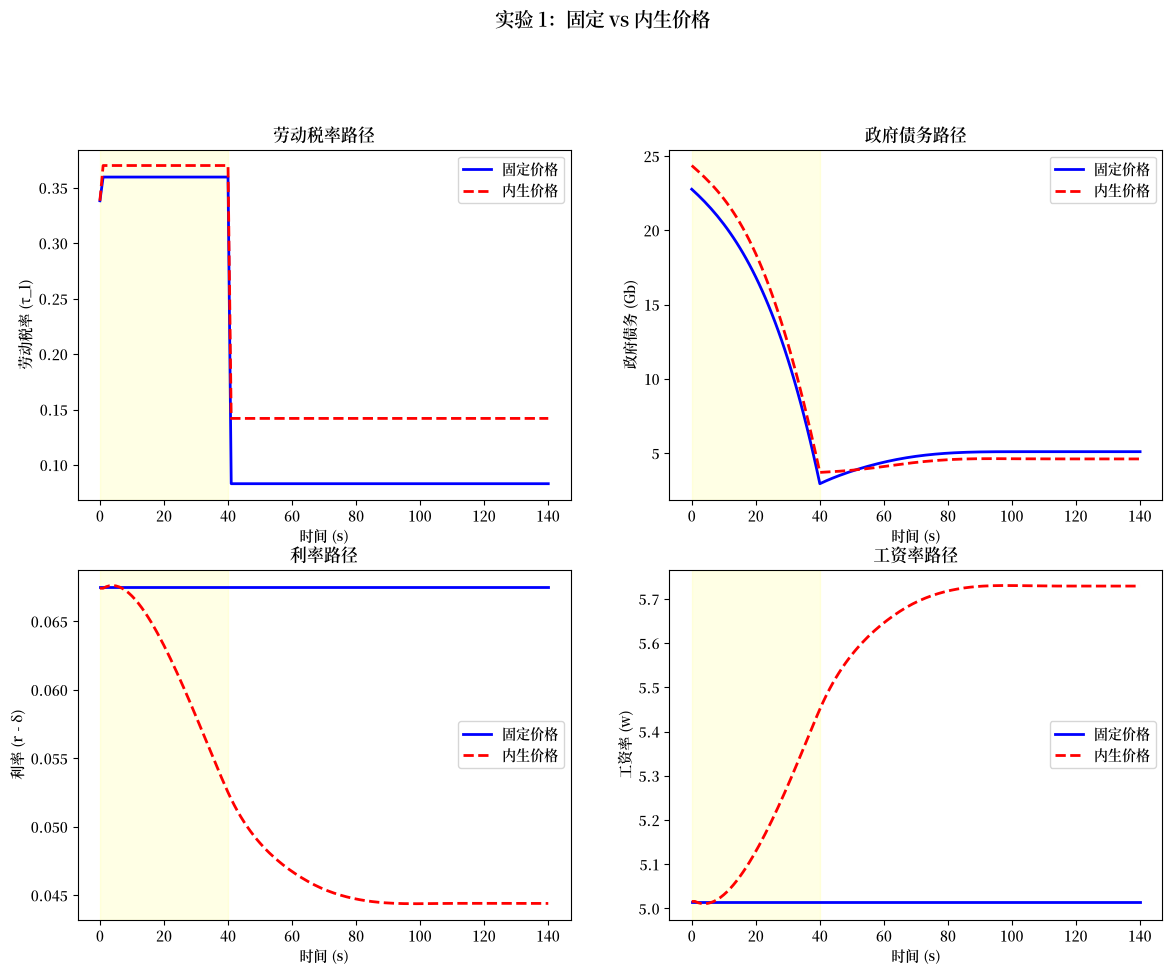

In [61]:
# 获取内生价格序列
price_seq_endo = exp1_endo['price_seq']
S_endo = price_seq_endo.shape[0] - 2

# 构造固定价格序列用于比较
RR_fixed = tech.RR
w_fixed = tech.w

# 对于固定价格，构造 τ_l 序列
τ_l_seq_fixed = np.zeros(S_exo + 1)
τ_l_seq_fixed[:S1 + 1] = ss0_exp1.τ_l
τ_l_seq_fixed[S1 + 1:S2 + 1] = exp1_exo['τ_l_buyout']
τ_l_seq_fixed[S2 + 1:] = ss1_exp1.τ_l

# 对于内生价格
τ_l_seq_endo = np.zeros(S_endo + 1)
τ_l_seq_endo[:S1 + 1] = exp1_endo['ss0'].τ_l
τ_l_seq_endo[S1 + 1:S2 + 1] = exp1_endo['τ_l_buyout']
τ_l_seq_endo[S2 + 1:] = exp1_endo['ss1'].τ_l

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 劳动税比较
axes[0, 0].plot(τ_l_seq_fixed, 'b-', linewidth=2, label='固定价格')
axes[0, 0].plot(τ_l_seq_endo[:len(τ_l_seq_fixed)],
                'r--', linewidth=2,
                label='内生价格')
axes[0, 0].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[0, 0].set_xlabel('时间 (s)')
axes[0, 0].set_ylabel('劳动税率 (τ_l)')
axes[0, 0].set_title('劳动税率路径')
axes[0, 0].legend()

# 政府债务比较
Gb_seq_fixed = Gb_seq_bo
Gb_seq_endo_exp1 = exp1_endo['Gb_seq']
axes[0, 1].plot(Gb_seq_fixed, 'b-', linewidth=2, label='固定价格')
axes[0, 1].plot(
    Gb_seq_endo_exp1[:len(Gb_seq_fixed)],
    'r--', linewidth=2,
    label='内生价格'
)
axes[0, 1].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[0, 1].set_xlabel('时间 (s)')
axes[0, 1].set_ylabel('政府债务 (Gb)')
axes[0, 1].set_title('政府债务路径')
axes[0, 1].legend()

# 利率比较
r_fixed = np.full(S_exo + 1, tech.r - tech.δ)
r_endo = price_seq_endo[:-1, 0] - 1  # RR - 1 = r - δ
axes[1, 0].plot(r_fixed, 'b-', linewidth=2, label='固定价格')
axes[1, 0].plot(
    r_endo[:len(r_fixed)],
    'r--', linewidth=2,
    label='内生价格'
)
axes[1, 0].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[1, 0].set_xlabel('时间 (s)')
axes[1, 0].set_ylabel('利率 (r - δ)')
axes[1, 0].set_title('利率路径')
axes[1, 0].legend()

# 工资率比较
w_fixed_seq = np.full(S_exo + 1, tech.w)
w_endo = price_seq_endo[:-1, 1]
axes[1, 1].plot(w_fixed_seq, 'b-', linewidth=2, label='固定价格')
axes[1, 1].plot(
    w_endo[:len(w_fixed_seq)],
    'r--', linewidth=2,
    label='内生价格'
)
axes[1, 1].axvspan(S1, S2, alpha=0.1, color='yellow')
axes[1, 1].set_xlabel('时间 (s)')
axes[1, 1].set_ylabel('工资率 (w)')
axes[1, 1].set_title('工资率路径')
axes[1, 1].legend()

plt.suptitle(
    '实验 1：固定 vs 内生价格',
    fontsize=14, y=1.02
)
plt.show()

左上图显示两种价格假设下的转型税率相似，但下方两图揭示了要素价格的重要差异。

随着资本存量在转型期间上升，在内生定价下利率下降而工资上升，而在小型开放经济假设下它们保持恒定。

这些价格效应产生了超出政策变化预期之外的额外再分配后果：较低的利率通过更高的工资使年轻工人受益，但通过较低的储蓄回报使退休人员受损。

## 实验 2：政府资本积累

在实验 2 中，政府维持社会保障福利，但暂时提高税收以积累实物资本。

这笔资本的回报最终为社会保障支付提供资金，因此在终端稳态中政府是净债权人而非债务人。

与消除福利的实验 1 不同，这种方法保留了社会保障的社会保险功能——即针对寿命风险的保险和针对劳动收入波动的部分保险。

通过让政府代表家庭进行储蓄，经济体可以在维持社会保障所提供的跨世代保险的同时实现更高的资本积累。

```{prf:algorithm} 固定要素价格 —— 实验 2（政府融资）
:label: two_comp_algo_govfund

这里 $s_3 = s_2 + T_0 = 105$。

步骤 1--3 与 {prf:ref}`two_comp_algo_buyout` 相同，只是社会保障福利被维持，且目标债务与GDP之比为负（政府成为净债权人）。

正确的目标促使政府积累足够的资本以从资产回报为福利提供资金。

步骤 4 是关于 $\tau_{\ell,1}$ 的相同根搜索过程，但没有补偿支付。
```

我们首先计算固定价格下的终端稳态，目标是使政府成为净债权人的负债务与GDP之比。

In [62]:
debt2gdp_target_exp2_exo = -1.1785
ss1_exp2_exo = ss_target_debt2gdp_exo(
    debt2gdp_target_exp2_exo,
    (τ_a_0, τ_0_0, benef_0, G_0),
    (RR_exo, w_exo), hh, tech
)

有了终端稳态，对转型税率进行二分给出固定价格下的均衡路径。

In [63]:
# 价格和政策序列
price_seq_exp2_exo = make_exo_price_seq(S_exo, RR_exo, w_exo)
policy_seq_exp2_exo = make_policy_seq(
    S_exo, ss0.τ_l, ss1_exp2_exo.τ_l,
    S1, S2,
    τ_a_0, τ_0_0, benef_0, G_0, Gb_0
)

# 求解（无补偿）
τ_l_exp2_exo, results_exp2_exo = find_transition_exo(
    price_seq_exp2_exo, policy_seq_exp2_exo, ss0, ss1_exp2_exo,
    hh, tech, S_exo, S1, S2
)

结果被打包以用于下面的跨实验比较。

In [64]:
(carryover_exp2, μx_seq_exp2_exo,
 μc_seq_exp2_exo, k_seq_exp2_exo,
 Gb_seq_exp2_exo, F_seq_exp2_exo,
 Ao_seq_exp2_exo) = results_exp2_exo
exp2_exo = {
    'ss0': ss0, 'ss1': ss1_exp2_exo,
    'τ_l_trans': τ_l_exp2_exo,
    'results': results_exp2_exo,
    'k_seq': k_seq_exp2_exo, 'Gb_seq': Gb_seq_exp2_exo,
    'μc_seq': μc_seq_exp2_exo, 'μx_seq': μx_seq_exp2_exo
}

我们在内生要素价格下重复计算，使用与实验 1 相同的初始稳态。

In [65]:
# 为初始 SS 计算内生价格（重用实验 1 的）
ss0_exp2_endo = ss0_exp1_endo  # 相同初始 SS

# 内生价格的终端稳态
ss1_exp2_endo = find_ss_endo(
    debt2gdp_target=-1.925,
    policy_target=(τ_a_0, τ_0_0, benef_0, G_0),
    hh=hh, tech=tech,
    RR_init=tech.RR, w_init=tech.w,
    verbose=True
)

    SS 迭代 0: RR=1.067500, w=5.0147, k_bar=43.5570
    SS 迭代 5: RR=1.044472, w=5.7664, k_bar=30.0436
    SS 迭代 10: RR=1.044623, w=5.7272, k_bar=30.0407
    SS 迭代 15: RR=1.044648, w=5.7206, k_bar=30.0403
    SS 迭代 20: RR=1.044651, w=5.7195, k_bar=30.0409
    SS 迭代 25: RR=1.044651, w=5.7193, k_bar=30.0409
    在迭代 29 收敛


    SS 迭代 5: RR=1.044472, w=5.7664, k_bar=30.0436


    SS 迭代 10: RR=1.044623, w=5.7272, k_bar=30.0407


    SS 迭代 15: RR=1.044648, w=5.7206, k_bar=30.0403


    SS 迭代 20: RR=1.044651, w=5.7195, k_bar=30.0409


    SS 迭代 25: RR=1.044651, w=5.7193, k_bar=30.0409


    在迭代 29 收敛


价格迭代产生内生价格转型路径。

In [66]:
# 初始化价格序列
price_seq_exp2_endo = init_price_seq_interp(
    S_endo, S1, S3,
    float(ss0_exp2_endo.RR), float(ss0_exp2_endo.w),
    float(ss1_exp2_endo.RR), float(ss1_exp2_endo.w)
)

# 政策序列
policy_seq_exp2_endo = make_policy_seq(
    S_endo,
    ss0_exp2_endo.τ_l, ss1_exp2_endo.τ_l,
    S1, S2,
    τ_a_0, τ_0_0, benef_0, G_0,
    ss0_exp2_endo.Gb
)

# 用价格迭代求解（无补偿）
endo2 = find_transition_endo(
    price_seq_exp2_endo, policy_seq_exp2_endo,
    ss0_exp2_endo, ss1_exp2_endo,
    hh, tech, S_endo, S1, S2, S3,
    verbose=True
)
τ_l_exp2_endo = endo2[0]
price_seq_exp2_endo_conv = endo2[1]
results_exp2_endo = endo2[2]
(_, μx_seq_exp2_endo, μc_seq_exp2_endo,
 k_seq_exp2_endo, Gb_seq_exp2_endo,
 _, _) = results_exp2_endo

  开始价格迭代...
  迭代 0: τ_l=0.3660, price_diff=0.394320
  迭代 1: τ_l=0.3769, price_diff=0.202210
  迭代 2: τ_l=0.3845, price_diff=0.103709
  迭代 3: τ_l=0.3891, price_diff=0.050465
  迭代 4: τ_l=0.3916, price_diff=0.022852
  迭代 5: τ_l=0.3928, price_diff=0.009652
  迭代 6: τ_l=0.3933, price_diff=0.003839
  迭代 7: τ_l=0.3935, price_diff=0.001457
  迭代 8: τ_l=0.3936, price_diff=0.000537
  在迭代 8 收敛


  迭代 1: τ_l=0.3769, price_diff=0.202210


  迭代 2: τ_l=0.3845, price_diff=0.103709
  迭代 3: τ_l=0.3891, price_diff=0.050465


  迭代 4: τ_l=0.3916, price_diff=0.022852


  迭代 5: τ_l=0.3928, price_diff=0.009652
  迭代 6: τ_l=0.3933, price_diff=0.003839


  迭代 7: τ_l=0.3935, price_diff=0.001457


  迭代 8: τ_l=0.3936, price_diff=0.000537
  在迭代 8 收敛


In [67]:
exp2_endo = {
    'ss0': ss0_exp2_endo, 'ss1': ss1_exp2_endo,
    'τ_l_trans': τ_l_exp2_endo,
    'price_seq': price_seq_exp2_endo_conv,
    'k_seq': k_seq_exp2_endo, 'Gb_seq': Gb_seq_exp2_endo,
    'results': results_exp2_endo,
    'μc_seq': μc_seq_exp2_endo, 'μx_seq': μx_seq_exp2_endo
}

我们现在比较所有四种改革方案：买断方案和政府融资方案，每种都在固定和内生要素价格下。

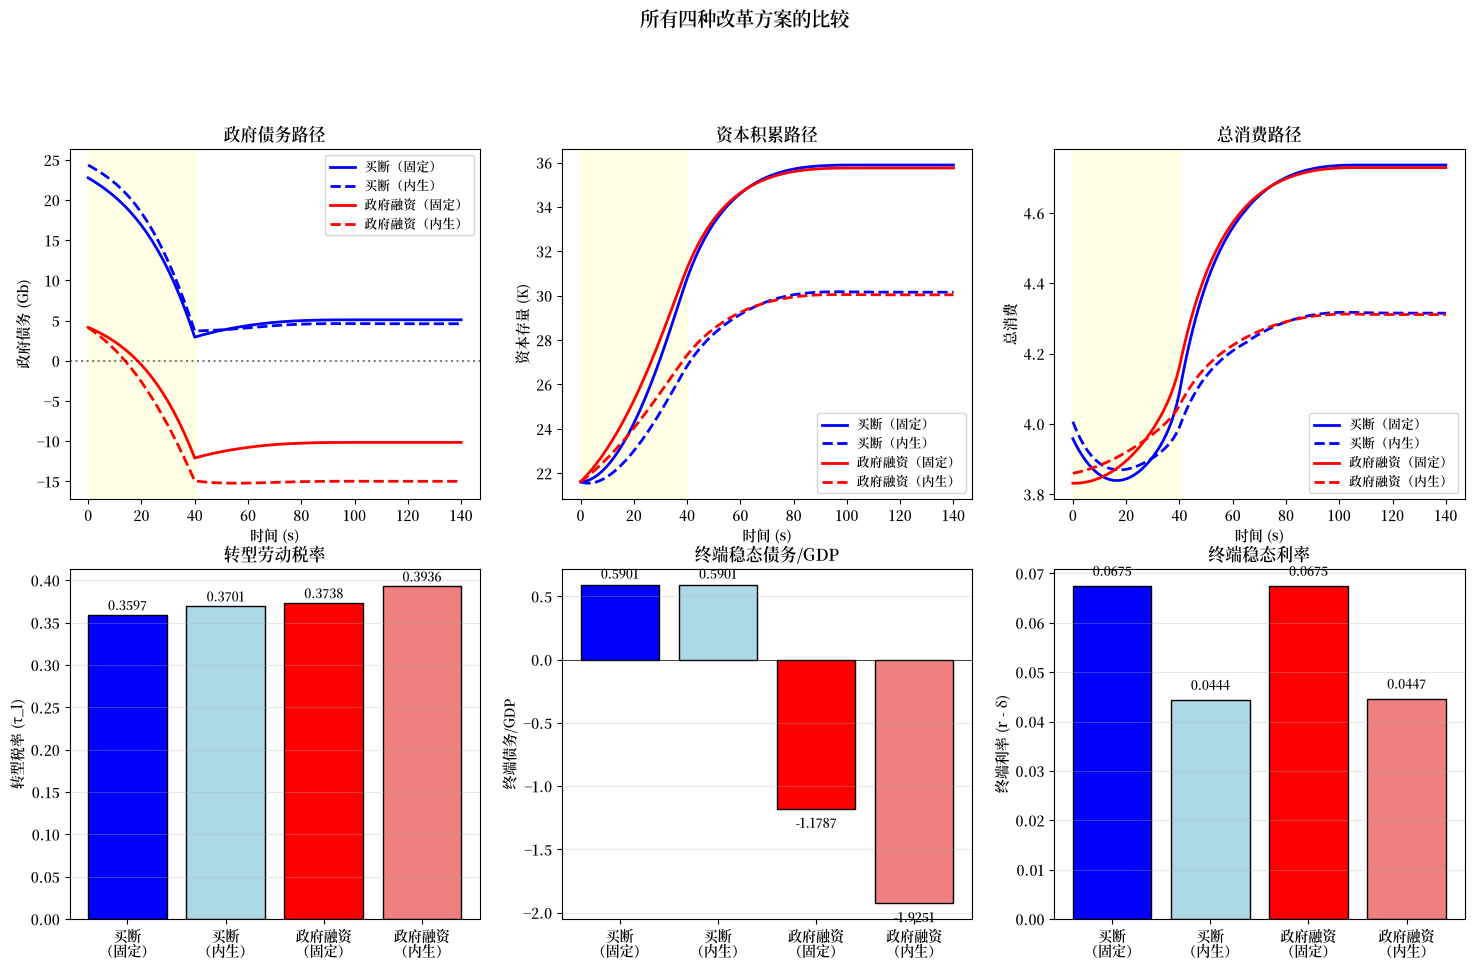

In [68]:
# 获取所有情形的债务序列
Gb_buyout_fixed = Gb_seq_bo
Gb_buyout_endo = exp1_endo['Gb_seq']
Gb_accum_fixed = exp2_exo['Gb_seq']
Gb_accum_endo = exp2_endo['Gb_seq']

# 获取资本序列
k_buyout_fixed = k_seq_bo
k_buyout_endo = exp1_endo['k_seq']
k_accum_fixed = exp2_exo['k_seq']
k_accum_endo = exp2_endo['k_seq']

# 绘图的公共时间视界
T_plot = min(len(Gb_buyout_fixed), len(Gb_buyout_endo), 
             len(Gb_accum_fixed), len(Gb_accum_endo))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 四种方案的标签
lb = ['买断（固定）', '买断（内生）',
      '政府融资（固定）', '政府融资（内生）']
ls = ['b-', 'b--', 'r-', 'r--']

# 政府债务路径
ax = axes[0, 0]
for d, s, l in zip(
    [Gb_buyout_fixed, Gb_buyout_endo,
     Gb_accum_fixed, Gb_accum_endo],
    ls, lb
):
    ax.plot(d[:T_plot], s, linewidth=2, label=l)
ax.axhline(0, color='k', linestyle=':', alpha=0.5)
ax.axvspan(0, 40, alpha=0.1, color='yellow')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('政府债务 (Gb)')
ax.set_title('政府债务路径')
ax.legend(fontsize=9)


# 资本路径
ax = axes[0, 1]
for d, s, l in zip(
    [k_buyout_fixed, k_buyout_endo,
     k_accum_fixed, k_accum_endo],
    ls, lb
):
    ax.plot(d[:T_plot], s, linewidth=2, label=l)
ax.axvspan(0, 40, alpha=0.1, color='yellow')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('资本存量 (K)')
ax.set_title('资本积累路径')
ax.legend(fontsize=9)


# 总消费
res2_exo = exp2_exo['results']
res1_endo = exp1_endo['results']
res2_endo = exp2_endo['results']
_, _, μc_exp2_exo, _, _, _, _ = res2_exo
_, _, μc_exp1_endo, _, _, _, _ = res1_endo
_, _, μc_exp2_endo, _, _, _, _ = res2_endo

def _agg_c(μc, T):
    """跨队列汇总人均消费。"""

    n = min(T, μc.shape[0])
    return np.array([
        np.sum(μc[s] * hh.frac) for s in range(n)
    ])

c_agg_buyout_fixed = c_agg_bo[:T_plot]
c_agg_buyout_endo = _agg_c(μc_exp1_endo, T_plot)
c_agg_accum_fixed = _agg_c(μc_exp2_exo, T_plot)
c_agg_accum_endo = _agg_c(μc_exp2_endo, T_plot)

ax = axes[0, 2]
for d, s, l in zip(
    [c_agg_buyout_fixed, c_agg_buyout_endo,
     c_agg_accum_fixed, c_agg_accum_endo],
    ls, lb
):
    ax.plot(d[:T_plot], s, linewidth=2, label=l)
axes[0, 2].axvspan(0, 40, alpha=0.1, color='yellow')
axes[0, 2].set_xlabel('时间 (s)')
axes[0, 2].set_ylabel('总消费')
axes[0, 2].set_title('总消费路径')
axes[0, 2].legend(fontsize=9)

# 条形图：转型税率
cases = ['买断\n（固定）', '买断\n（内生）',
         '政府融资\n（固定）', '政府融资\n（内生）']
τ_l_values = [exp1_exo['τ_l_buyout'], exp1_endo['τ_l_buyout'], 
              exp2_exo['τ_l_trans'], exp2_endo['τ_l_trans']]
colors = ['blue', 'lightblue', 'red', 'lightcoral']
axes[1, 0].bar(cases, τ_l_values, color=colors, edgecolor='black')
axes[1, 0].set_ylabel('转型税率 (τ_l)')
axes[1, 0].set_title('转型劳动税率')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(τ_l_values):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

# 条形图：终端债务/GDP
debt2gdp_values = [exp1_exo['ss1'].debt2gdp, exp1_endo['ss1'].debt2gdp,
                   exp2_exo['ss1'].debt2gdp, exp2_endo['ss1'].debt2gdp]
axes[1, 1].bar(cases, debt2gdp_values, color=colors, edgecolor='black')
axes[1, 1].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].set_ylabel('终端债务/GDP')
axes[1, 1].set_title('终端稳态债务/GDP')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(debt2gdp_values):
    y = v + 0.05 if v > 0 else v - 0.15
    axes[1, 1].text(
        i, y, f'{v:.4f}',
        ha='center', fontsize=9
    )

# 条形图：终端利率
r_values = [exp1_exo['ss1'].r - tech.δ, exp1_endo['ss1'].r - tech.δ,
            exp2_exo['ss1'].r - tech.δ, exp2_endo['ss1'].r - tech.δ]
axes[1, 2].bar(cases, r_values, color=colors, edgecolor='black')
axes[1, 2].set_ylabel('终端利率 (r - δ)')
axes[1, 2].set_title('终端稳态利率')
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r_values):
    axes[1, 2].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('所有四种改革方案的比较', fontsize=14, y=1.02)
plt.show()

顶行比较转型动态：买断方案（蓝色）由于补偿支付在转型期间积累更高的债务，而政府融资方案（红色）导致大额负债务，因为政府成为净债权人。

左下条形图显示政府融资需要比买断方案更高的转型税率，因为福利支付与资本积累同时进行。

在内生定价下，更大的资本存量降低了资本的边际产量从而降低了利率，如右下图所示。

政府融资方案（实验 2）带来更大的长期效率增益，因为它保留了针对寿命风险和劳动收入波动的保险，而这些在私有化下将会丧失。

转型期间较高的劳动收入税率也针对收入风险提供隐性保险，在内生价格下放大了效率优势。

## 分布曲面

下面的 3D 曲面图显示资产和消费如何在年龄维度和日历时间两个维度上演变。

In [69]:
# 计算用于 3D 绘图的方差
def compute_variances(results, ss0, hh):
    """从转型结果计算方差序列。"""

    _, μx_seq, μc_seq, k_seq, Gb_seq, F_seq, Ao_seq = results
    
    # 转换为 numpy
    μx_seq = np.array(μx_seq)
    μc_seq_full = np.array(μc_seq)
    F_seq = np.array(F_seq)
    Ao_seq = np.array(Ao_seq)
    Σx_arr_ss0 = np.array(ss0.Σx_arr)
    Σ0 = np.array(hh.Σ0)
    C = np.array(hh.C)
    
    # 从数据获取实际维度
    S_plus_1 = Ao_seq.shape[0]  # S+1
    T0_plus_1 = Ao_seq.shape[1]  # T0+1
    
    Σx_seq = np.empty((S_plus_1 + 1, T0_plus_1 + 1, hh.n_x, hh.n_x))
    Vc_seq = np.empty((S_plus_1, T0_plus_1))
    Va_seq = np.empty((S_plus_1, T0_plus_1))
    
    Σx_seq[:, 0] = Σ0
    Σx_seq[0, :] = Σx_arr_ss0[:T0_plus_1 + 1]
    
    CCT = C @ C.T
    for s in range(S_plus_1):
        Ao_s = Ao_seq[s]                    # (T0+1, n_x, n_x)
        Σx_s = Σx_seq[s, :T0_plus_1]        # (T0+1, n_x, n_x)
        F_s = F_seq[s]                       # (T0+1, n_x)
        Σx_seq[s + 1, 1:] = CCT + Ao_s @ Σx_s @ Ao_s.transpose(0, 2, 1)
        Vc_seq[s] = np.einsum('ti,tij,tj->t', F_s, Σx_s, F_s)
        Va_seq[s] = Σx_s[:, 0, 0]
    
    # 提取平均资产 - 与 Ao_seq 匹配维度
    μa_seq = μx_seq[:S_plus_1, :T0_plus_1, 0]
    μc_seq_out = μc_seq_full[:S_plus_1, :T0_plus_1]
    
    return μa_seq, Va_seq, μc_seq_out, Vc_seq

# 为每种情形计算方差
μa_bf, Va_bf, μc_bf, Vc_bf = compute_variances(
    exp1_exo['results_buyout'], exp1_exo['ss0'], hh
)
μa_be, Va_be, μc_be, Vc_be = compute_variances(
    exp1_endo['results'], exp1_endo['ss0'], hh
)
μa_af, Va_af, μc_af, Vc_af = compute_variances(
    exp2_exo['results'], exp2_exo['ss0'], hh
)
μa_ae, Va_ae, μc_ae, Vc_ae = compute_variances(
    exp2_endo['results'], exp2_endo['ss0'], hh
)

case_names = [
    '买断（固定）', '买断（内生）',
    '政府融资（固定）', '政府融资（内生）'
]


def plot_surface_grid(
        data_cases, case_names, zlabel,
        suptitle, cmap='viridis',
        transform=None):
    """为年龄-时间数据绘制 2x2 的 3D 曲面网格。"""

    fig = plt.figure(figsize=(16, 12))
    for i, (data, name) in enumerate(zip(data_cases, case_names)):
        Z = transform(data) if transform is not None else data
        n_time, n_age = Z.shape
        X, Y = np.meshgrid(np.arange(n_age), np.arange(n_time))
        ax = fig.add_subplot(2, 2, i + 1, projection='3d')
        ax.plot_surface(X, Y, Z, cmap=cmap, edgecolor='none', alpha=0.8)
        ax.set_xlabel('年龄 (t)')
        ax.set_ylabel('时间 (s)')
        ax.set_zlabel(zlabel)
        ax.set_title(name)
    plt.suptitle(suptitle, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

每个曲面显示跨年龄（$t$）和日历时间（$s$）的联合分布，揭示生命周期模式、转型动态和跨队列异质性。

平均资产曲面显示资产持有的驼峰形生命周期剖面，随着工作世代响应改革增加储蓄，峰值资产发生移动。

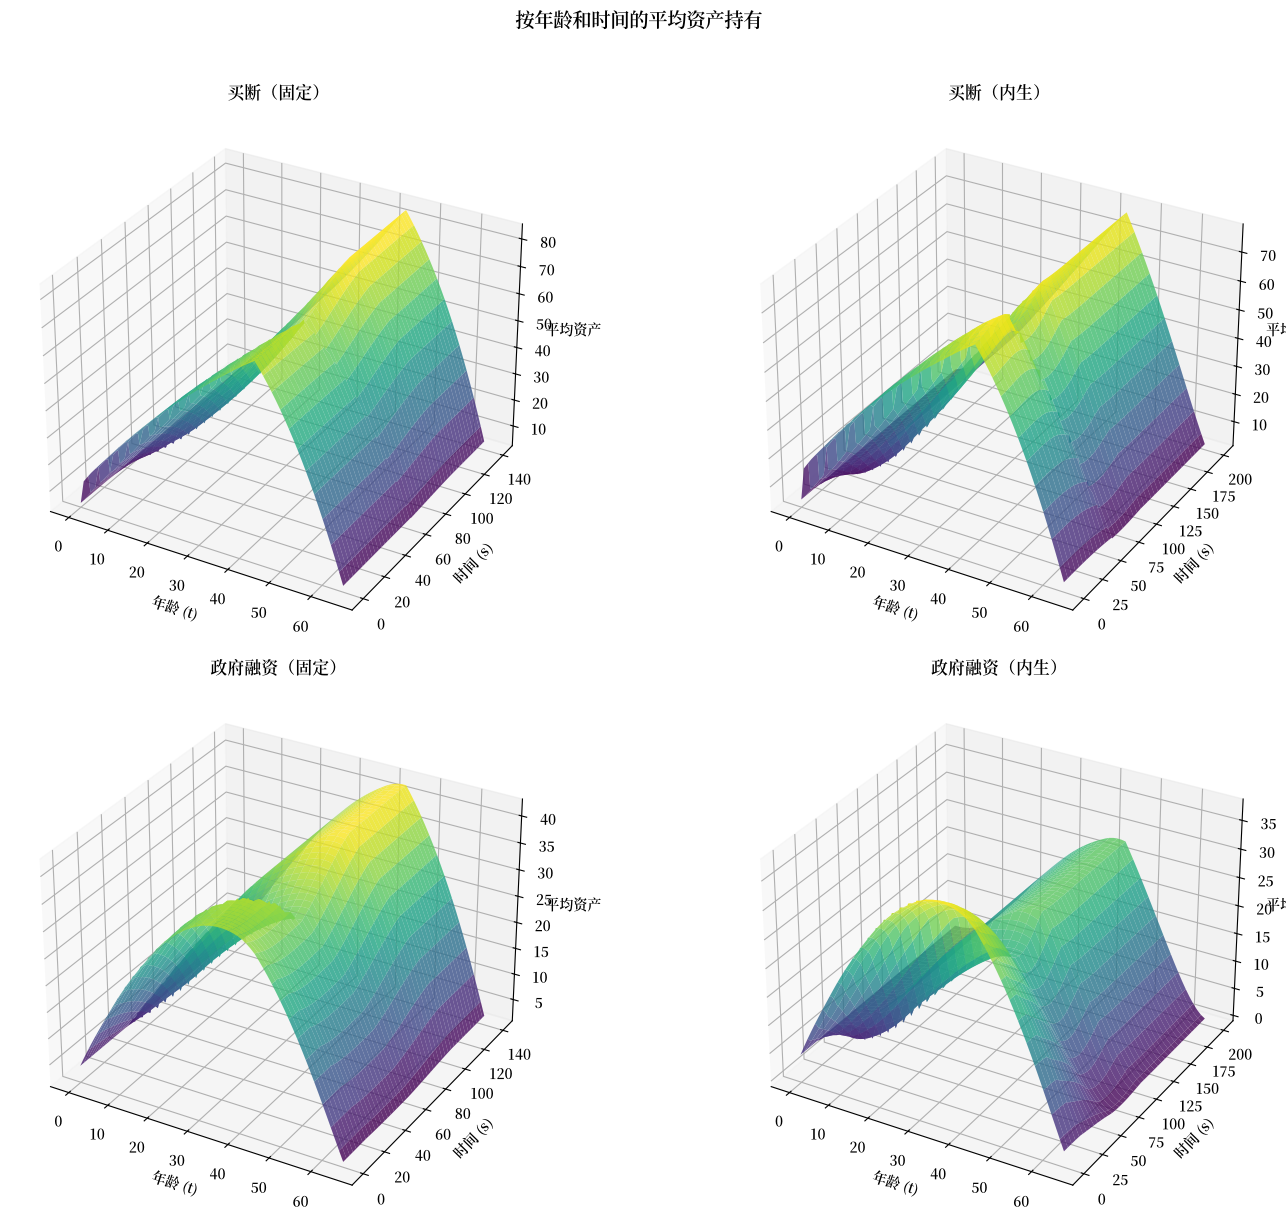

In [70]:
plot_surface_grid(
    [μa_bf, μa_be, μa_af, μa_ae],
    case_names, '平均资产',
    '按年龄和时间的平均资产持有'
)

资产方差曲面显示累积收入冲击如何导致离散度随年龄增加，转型可能改变离散度增长的速率。

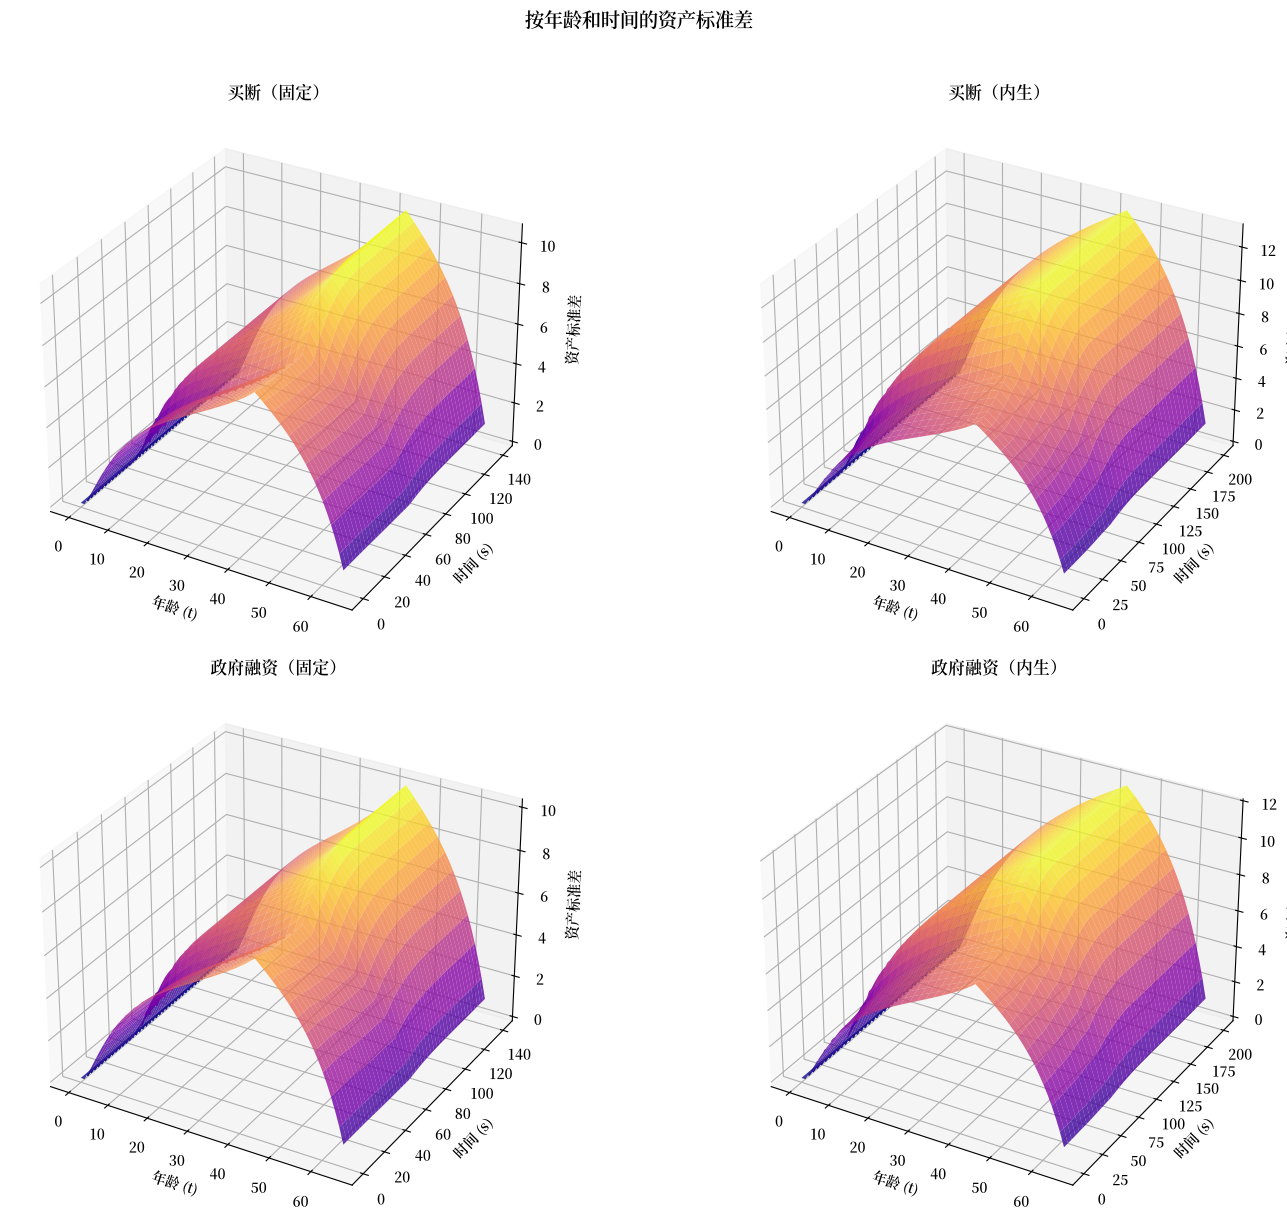

In [71]:
plot_surface_grid(
    [Va_bf, Va_be, Va_af, Va_ae],
    case_names, '资产标准差',
    '按年龄和时间的资产标准差',
    cmap='plasma', transform=np.sqrt
)

平均消费曲面反映最优消费路径，由于模型基础的持久收入假设，该路径应在各年龄间平滑。

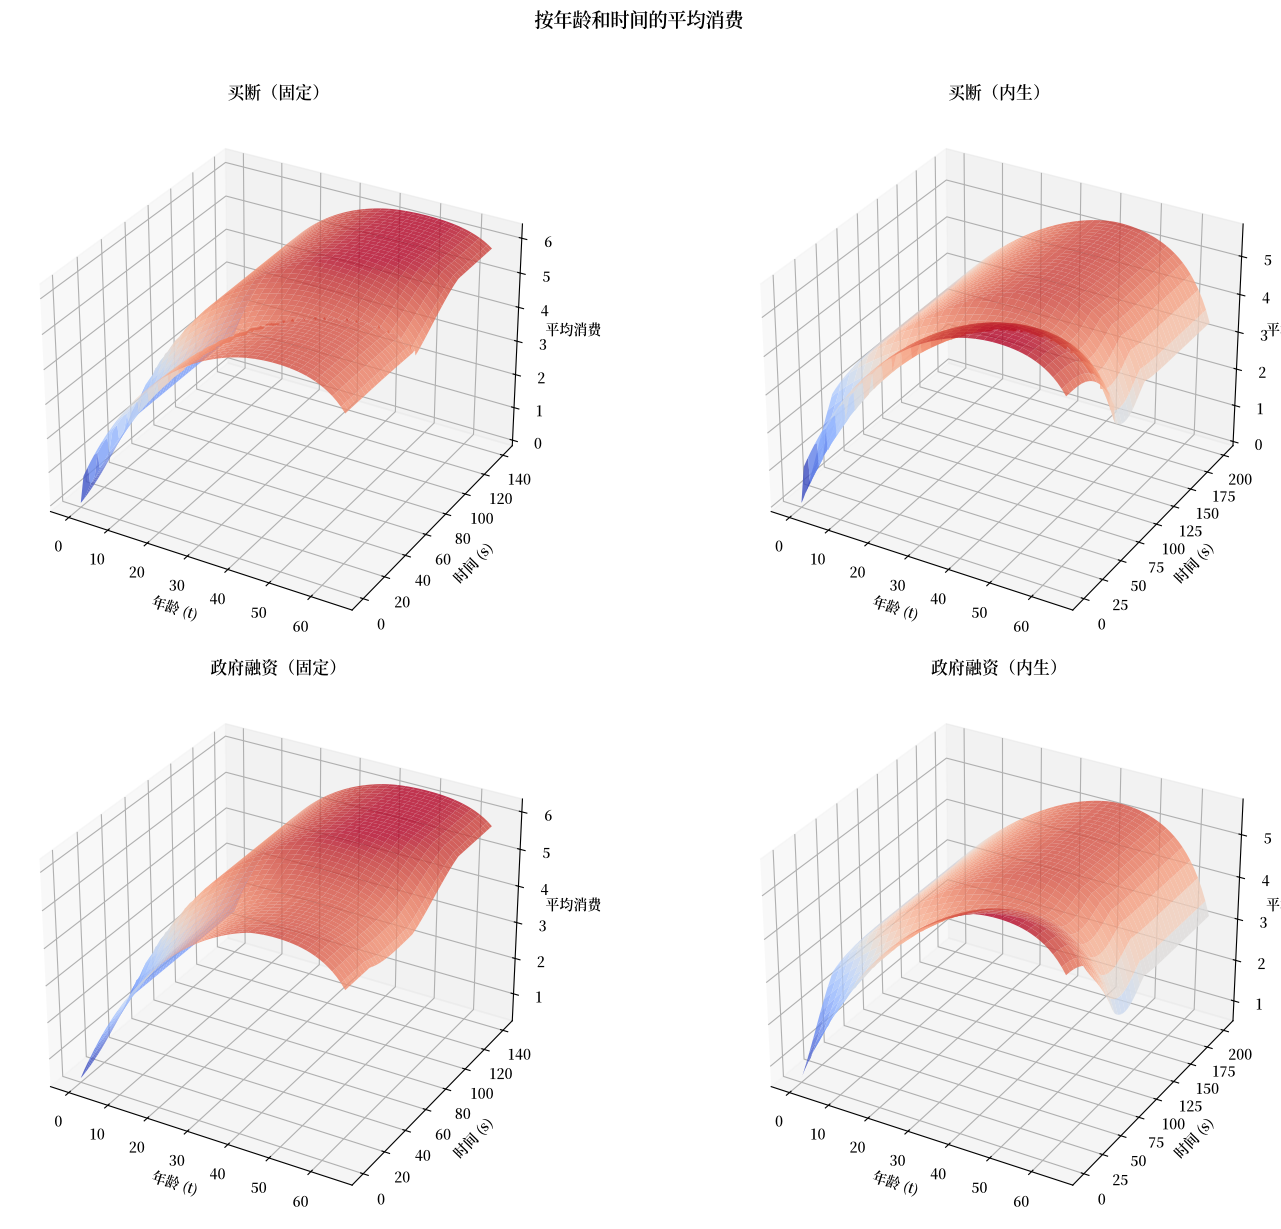

In [72]:
plot_surface_grid(
    [μc_bf, μc_be, μc_af, μc_ae],
    case_names, '平均消费',
    '按年龄和时间的平均消费',
    cmap='coolwarm'
)

消费方差曲面揭示 LQ 框架的确定性等价性质如何随时间塑造队列内的消费分布。

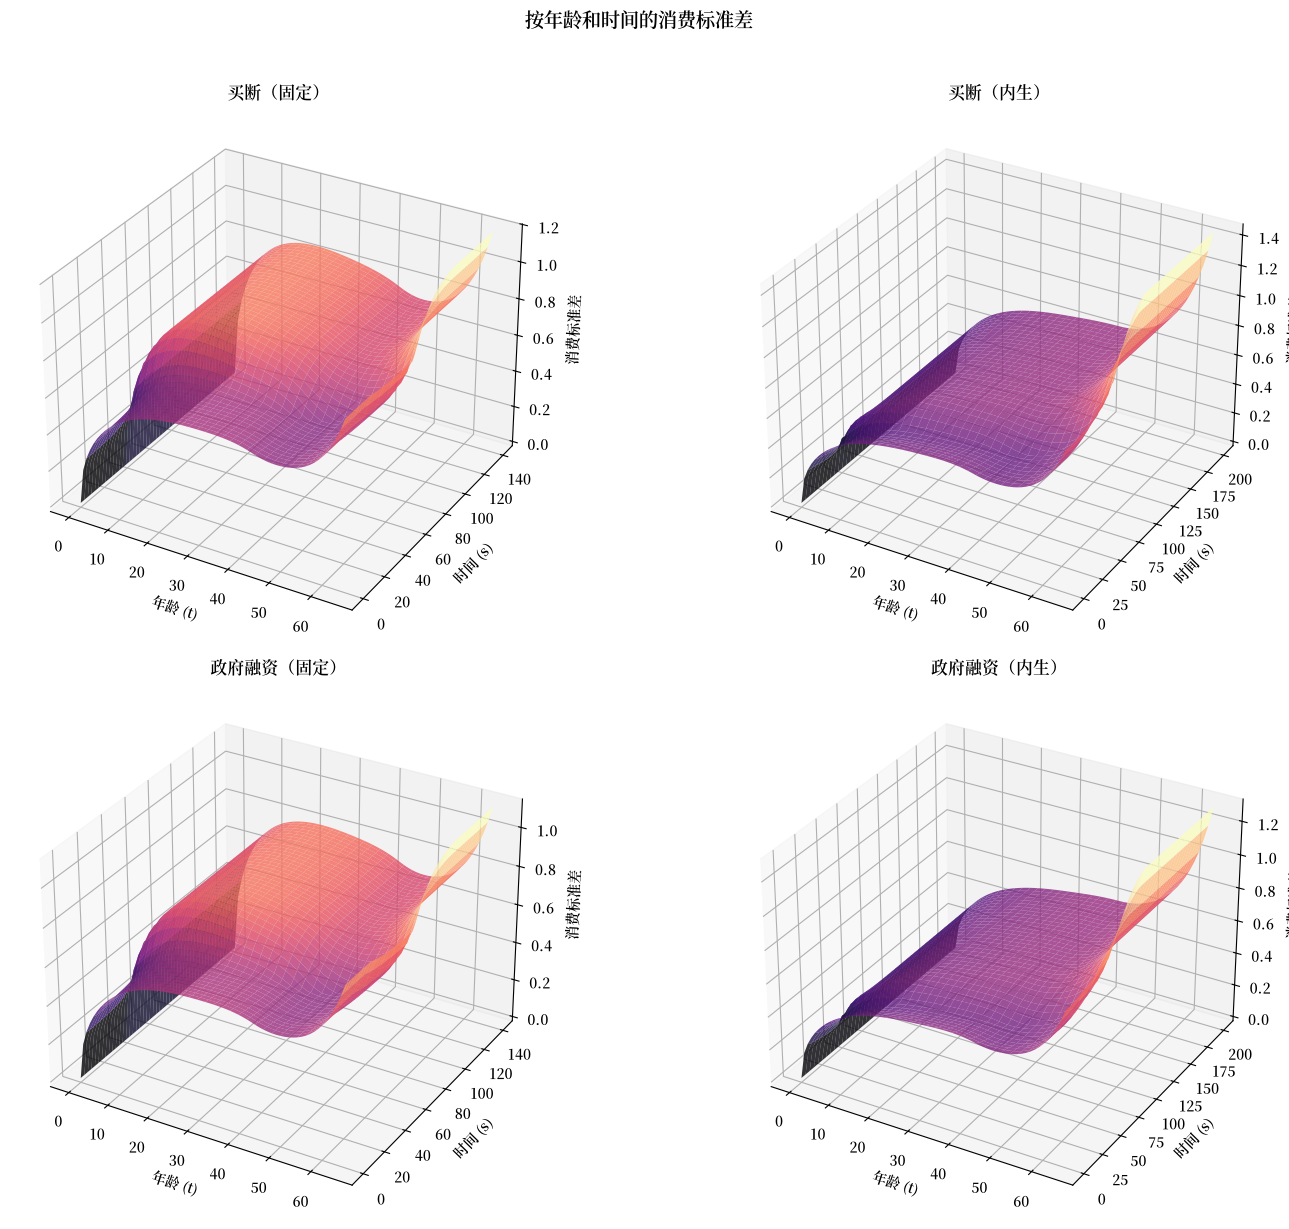

In [73]:
plot_surface_grid(
    [Vc_bf, Vc_be, Vc_af, Vc_ae],
    case_names, '消费标准差',
    '按年龄和时间的消费标准差',
    cmap='magma', transform=np.sqrt
)